# SWALIM Flood Threshold Exceedance

Compares, across SWALIM river gauge stations, how often observed water
levels reach the **Moderate** and **High** Flood Risk thresholds: how
often, how severe, whether stations flood together, and the return period
of each threshold.

- Levels: `ds-aa-som-floods/raw/swalim/snrfa_level_data_<code> - <station>.csv`
- Thresholds: `ds-aa-som-floods/raw/swalim/Search Data  SNRFA.csv`


**Which gauges carry the trigger.** This notebook characterises every
SWALIM station with a usable record, because the threshold and event
analysis is worth having for all of them. The trigger itself is built
only on the gauges that are still reporting: Luuq, Dollow, Bardheere
and Bualle on the Juba, and Belet Weyne, Bulo Burti and Jowhar on the
Shabelle (`TRIGGER_STATIONS` in `src/constants.py`). Kaitoi, Afgoi,
Audegle and Mahadey Weyne appear below but stop reporting in 2008 or
earlier, so they can calibrate and cannot monitor.


## Thresholds

In [1]:
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

import sys

sys.path.insert(0, "..")

import os
import tempfile
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import ocha_stratus as stratus
import geopandas as gpd, tempfile, os
from matplotlib.ticker import FuncFormatter

from src.datasources.swalim import (
    list_station_blobs,
    load_station_levels,
    load_thresholds,
)
from src.constants import (
    TRIGGER_STATIONS,
    ALL_TRIGGER_STATIONS,
    SEASONS,
    SEASON_MONTHS,
    EXP_SEASONS,
    STATIONS,
    INK,
    BODY,
    FAINT,
    GRID,
    C_MOD,
    C_HIGH,
    C_GU,
    C_DEYR,
    C_JUBA,
    C_SHAB,
    C_MAIN,
    C_ISOL,
    C_JOINT,
    C_BAND,
    C_BAND_EDGE,
    C_REF,
    C_GEOGLOWS,
    C_GOOGLE,
    C_GLOFAS4,
    C_GLOFAS5,
    C_SWALIM,
    C_SFED,
    SOURCE_COLORS,
)
from src.plots import apply_chart_style, style_ax
from src.utils import (
    annual_maxima,
    auc,
    compute_threshold_stats,
    episodes,
    event_periods,
    gumbel_rp,
    hits,
    return_period_for_level,
    return_periods_table,
    system_events_table,
    weibull_level,
    weibull_threshold,
    yT,
)

apply_chart_style()

In [2]:
thresholds = load_thresholds()
thresholds["Label"] = (
    thresholds["Station Name"] + " (" + thresholds["River"] + ")"
)
thresholds[
    [
        "Station Name",
        "River",
        "Status",
        "Moderate Flood Risk",
        "High Flood Risk",
        "Bank Full",
    ]
]

,Station Name,River,Status,Moderate Flood Risk,High Flood Risk,Bank Full
Station Number,,,,,,
jb001,Luuq,Juba,Functional,5.5,6.00,7.0
jb009,Dollow,Juba,Functional,4.5,5.00,6.0
jb002,Bardheere,Juba,Non Functional,7.4,8.20,10.4
jb004,Kaitoi,Juba,Non Functional,NaN,NaN,NaN
jb010,Bualle,Juba,Non Functional,9.0,10.00,12.0
sh001,Belet Weyne,Shabelle,Functional,6.5,7.30,8.3
sh002,Bulo Burti,Shabelle,Functional,6.5,7.20,8.0
sh004,Jowhar,Shabelle,Functional,5.0,5.25,5.5
sh003,Mahadey Weyne,Shabelle,Non Functional,NaN,NaN,NaN


## Load station level data

Loads every per-station SWALIM level file from blob. A handful of station
files are header-only (gauges that were never activated) and are skipped.

In [3]:
levels = {}
for blob_name in list_station_blobs():
    df = load_station_levels(blob_name)
    if len(df) == 0:
        continue
    levels[df["station_number"].iloc[0]] = df

print(f"{len(levels)} stations with data")

11 stations with data


## Exceedance frequency: Moderate vs High Risk

For each station, a flood *event* is defined as: the threshold is crossed,
then the water stays below it for at least 14 days before the next event
starts (a new event only starts on a genuine gap since the *previous*
exceedance day: a single long flood is always one event, however long it
runs). Stations with no threshold value on record for either level (mostly
non-functional gauges with missing metadata) are dropped automatically.

In [4]:
MIN_RECESSION_DAYS = (
    14  # water must stay below threshold this long to end an event
)

summary_mod, station_events_mod, exceed_mod = compute_threshold_stats(
    levels, thresholds, "Moderate Flood Risk", MIN_RECESSION_DAYS
)
summary_high, station_events_high, exceed_high = compute_threshold_stats(
    levels, thresholds, "High Flood Risk", MIN_RECESSION_DAYS
)
summary_mod

,station_name,threshold_m,n_obs_days,record_years,n_exceed_days,pct_days_exceed,n_events,events_per_year
station_number,,,,,,,,
sh004,Jowhar (Shabelle),5.0,9647,27.540041,1091,11.309215,43,1.561363
jb009,Dollow (Juba),4.5,3710,11.310062,173,4.663073,17,1.503086
jb002,Bardheere (Juba),7.4,13742,60.490075,365,2.656091,32,0.529012
sh001,Belet Weyne (Shabelle),6.5,17880,63.233402,837,4.681208,33,0.521876
sh002,Bulo Burti (Shabelle),6.5,14866,63.206023,457,3.074129,24,0.379711
jb001,Luuq (Juba),5.5,19455,75.312799,128,0.657929,21,0.278837
jb010,Bualle (Juba),9.0,5757,16.035592,29,0.503735,1,0.062361
jb004,Kaitoi (Juba),NaN,3002,NaN,0,NaN,0,NaN
sh003,Mahadey Weyne (Shabelle),NaN,7062,NaN,0,NaN,0,NaN


In [5]:
summary_high

,station_name,threshold_m,n_obs_days,record_years,n_exceed_days,pct_days_exceed,n_events,events_per_year
station_number,,,,,,,,
jb009,Dollow (Juba),5.00,3710,11.310062,75,2.021563,12,1.061002
sh004,Jowhar (Shabelle),5.25,9647,27.540041,342,3.545144,29,1.053012
sh001,Belet Weyne (Shabelle),7.30,17880,63.233402,466,2.606264,22,0.347917
jb002,Bardheere (Juba),8.20,13742,60.490075,142,1.033328,19,0.314101
sh002,Bulo Burti (Shabelle),7.20,14866,63.206023,211,1.419346,12,0.189855
jb001,Luuq (Juba),6.00,19455,75.312799,60,0.308404,9,0.119502
jb010,Bualle (Juba),10.00,5757,16.035592,25,0.434254,1,0.062361
jb004,Kaitoi (Juba),NaN,3002,NaN,0,NaN,0,NaN
sh003,Mahadey Weyne (Shabelle),NaN,7062,NaN,0,NaN,0,NaN


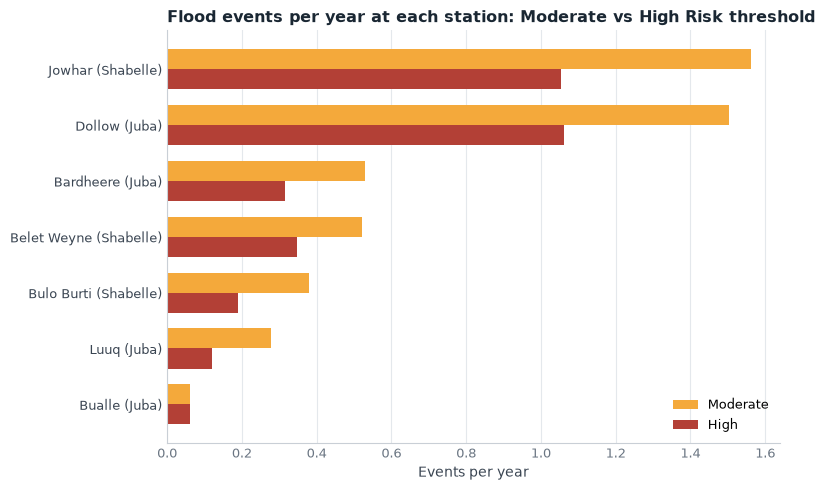

In [6]:
stations_both = summary_mod.dropna(
    subset=["events_per_year"]
).index.intersection(summary_high.dropna(subset=["events_per_year"]).index)

compare = pd.DataFrame(
    {
        "station_name": summary_mod.loc[stations_both, "station_name"],
        "moderate": summary_mod.loc[stations_both, "events_per_year"],
        "high": summary_high.loc[stations_both, "events_per_year"],
    }
).sort_values("moderate")

fig, ax = plt.subplots(figsize=(8, 5))
y = np.arange(len(compare))
height = 0.36
ax.barh(
    y + height / 2, compare["moderate"], height, color=C_MOD, label="Moderate"
)
ax.barh(y - height / 2, compare["high"], height, color=C_HIGH, label="High")
ax.set_yticks(y)
ax.set_yticklabels(compare["station_name"])
ax.set_xlabel("Events per year")
ax.set_title(
    "Flood events per year at each station: Moderate vs High Risk threshold"
)
ax.legend(loc="lower right")
style_ax(ax)
plt.tight_layout()
plt.show()

## Return period: Moderate vs High Risk

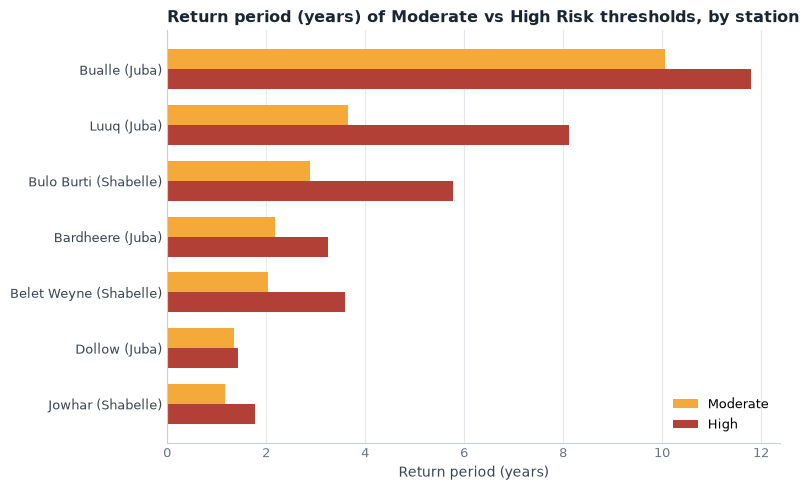

In [7]:
return_periods_mod = return_periods_table(
    levels, thresholds, "Moderate Flood Risk", station_events_mod, summary_mod
)
return_periods_high = return_periods_table(
    levels, thresholds, "High Flood Risk", station_events_high, summary_high
)

rp_compare = pd.DataFrame(
    {
        "station_name": return_periods_mod["station_name"],
        "moderate_years": return_periods_mod["return_period_annual_max"],
        "high_years": return_periods_high["return_period_annual_max"].reindex(
            return_periods_mod.index
        ),
    }
).sort_values("moderate_years")

fig, ax = plt.subplots(figsize=(8, 5))
y = np.arange(len(rp_compare))
height = 0.36
ax.barh(
    y + height / 2,
    rp_compare["moderate_years"],
    height,
    color=C_MOD,
    label="Moderate",
)
ax.barh(
    y - height / 2,
    rp_compare["high_years"],
    height,
    color=C_HIGH,
    label="High",
)
ax.set_yticks(y)
ax.set_yticklabels(rp_compare["station_name"])
ax.set_xlabel("Return period (years)")
ax.set_title(
    "Return period (years) of Moderate vs High Risk thresholds, by station"
)
ax.legend(loc="lower right")
style_ax(ax)
plt.tight_layout()
plt.show()

A simpler way to read the same thing: in what share of years does each
station reach each threshold at least once?

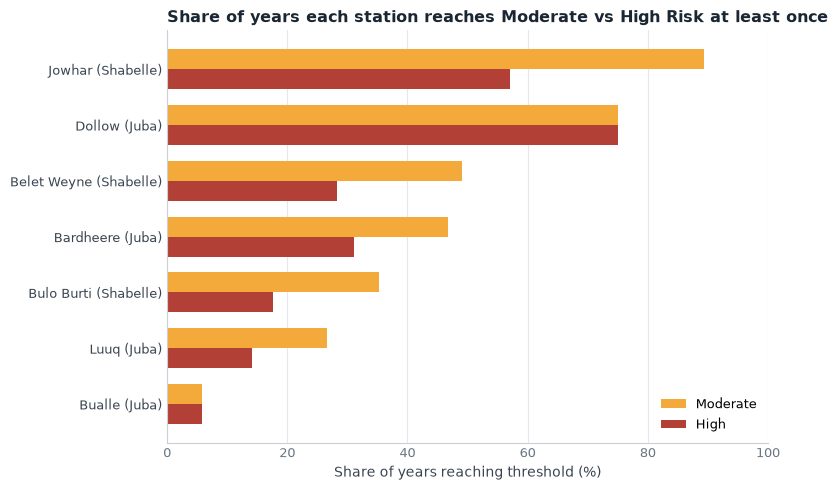

In [8]:
pct_compare = pd.DataFrame(
    {
        "station_name": return_periods_mod["station_name"],
        "moderate": return_periods_mod["pct_years_at_or_above"],
        "high": return_periods_high["pct_years_at_or_above"].reindex(
            return_periods_mod.index
        ),
    }
).sort_values("moderate")

fig, ax = plt.subplots(figsize=(8, 5))
y = np.arange(len(pct_compare))
height = 0.36
ax.barh(
    y + height / 2,
    pct_compare["moderate"],
    height,
    color=C_MOD,
    label="Moderate",
)
ax.barh(
    y - height / 2, pct_compare["high"], height, color=C_HIGH, label="High"
)
ax.set_yticks(y)
ax.set_yticklabels(pct_compare["station_name"])
ax.set_xlabel("Share of years reaching threshold (%)")
ax.set_xlim(0, 100)
ax.set_title(
    "Share of years each station reaches Moderate vs High Risk at least once"
)
ax.legend(loc="lower right")
style_ax(ax)
plt.tight_layout()
plt.show()

## Do stations flood at the same time? (Moderate Flood Risk)

**What counts as a flood event:** a continuous spell in which the station's
SWALIM water level sits at or above its official Moderate Flood Risk
threshold. Consecutive above-threshold days merge into one event, and the
event only ends once the level has stayed below the threshold for more
than 14 days, so a brief mid-flood dip does not split one flood into two.
Each event is a (start, end) period.

**How the matrix reads:** for row station A and column station B, over the
period where both stations have records: the % of A's events that overlap
any B event within a 14-day tolerance. Caveat: Bualle's 100% row rests on
a single usable event (the basin-wide 2023 flood), not on strong coupling. Stations are
ordered by river and elevation (upstream to downstream) as a proxy for
river position, since gauges on the same river are expected to see the
same flood pulse arrive with a lag. This section (and the two that follow
it) uses the **Moderate** threshold, since High Risk events are too sparse
per station for a meaningful pairwise breakdown.

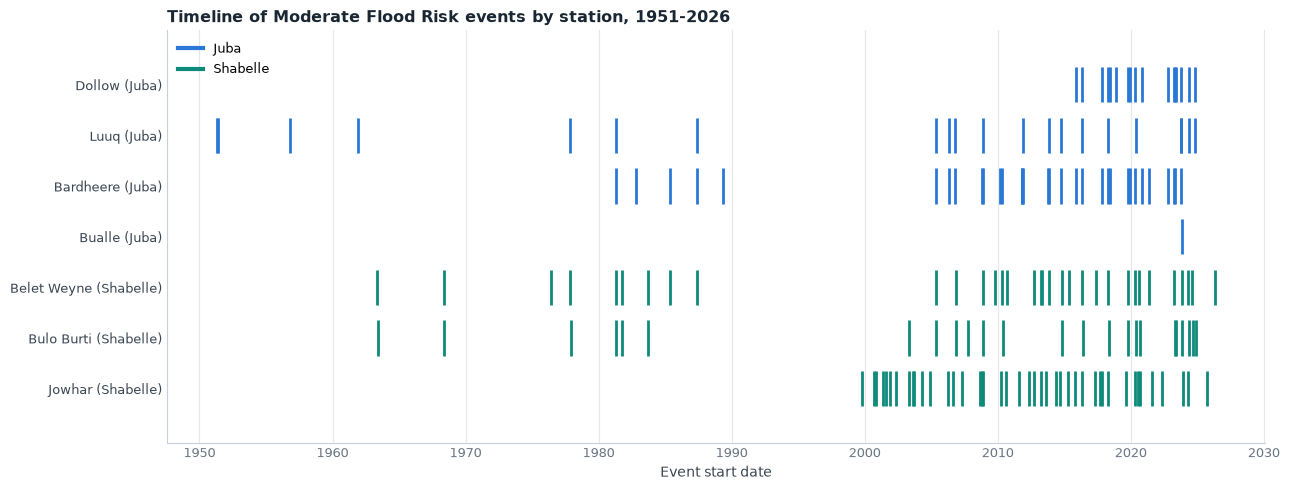

In [9]:
RIVER_COLORS = {"Juba": C_JUBA, "Shabelle": C_SHAB}

ordered = thresholds.loc[list(station_events_mod.keys())].sort_values(
    ["River", "Elevation"], ascending=[True, False]
)

fig, ax = plt.subplots(figsize=(13, 5))

for i, (station_number, row) in enumerate(ordered.iterrows()):
    starts = station_events_mod[station_number]["start"]
    ax.eventplot(
        starts,
        lineoffsets=i,
        linelengths=0.7,
        linewidths=2,
        colors=RIVER_COLORS[row["River"]],
    )

ax.set_yticks(range(len(ordered)))
ax.set_yticklabels(ordered["Label"])
ax.set_xlabel("Event start date")
ax.set_title("Timeline of Moderate Flood Risk events by station, 1951-2026")
ax.invert_yaxis()

handles = [
    plt.Line2D([0], [0], color=c, lw=3, label=r)
    for r, c in RIVER_COLORS.items()
]
ax.legend(handles=handles, loc="upper left")
style_ax(ax)
plt.tight_layout()
plt.show()

Blank stretches before a station's own record begins reflect missing data,
not an absence of floods (e.g. Jowhar's record starts in 1999, Dollow's in
2015). To quantify co-occurrence fairly, each station pair below is compared
only over the years both gauges were recording, and an event counts as
"shared" if the two stations' event windows fall within 14 days of each
other (allowing for travel time between gauges on the same river).

In [10]:
TOLERANCE_DAYS = 14

record_range = {
    sn: (
        df["level(m)"].dropna().index.min(),
        df["level(m)"].dropna().index.max(),
    )
    for sn, df in levels.items()
    if sn in station_events_mod
}


def overlap_rate(sn_a, sn_b):
    lo = max(record_range[sn_a][0], record_range[sn_b][0])
    hi = min(record_range[sn_a][1], record_range[sn_b][1])
    a = station_events_mod[sn_a]
    a = a[(a["start"] <= hi) & (a["end"] >= lo)]
    b = station_events_mod[sn_b]
    b = b[(b["start"] <= hi) & (b["end"] >= lo)]
    if len(a) == 0:
        return float("nan"), 0
    b_lo = b["start"] - pd.Timedelta(days=TOLERANCE_DAYS)
    b_hi = b["end"] + pd.Timedelta(days=TOLERANCE_DAYS)
    matched = sum(
        ((ev.start <= b_hi) & (ev.end >= b_lo)).any() for ev in a.itertuples()
    )
    return 100 * matched / len(a), len(a)


stations = list(ordered.index)
matrix = pd.DataFrame(index=stations, columns=stations, dtype=float)

for sn_a in stations:
    for sn_b in stations:
        if sn_a == sn_b:
            continue
        rate, n = overlap_rate(sn_a, sn_b)
        matrix.loc[sn_a, sn_b] = rate

matrix.index = ordered["Label"]
matrix.columns = ordered["Label"]

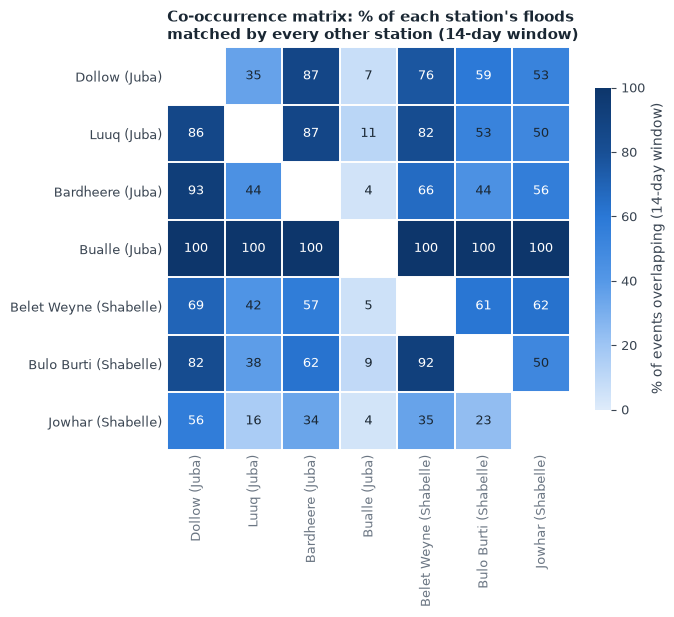

In [11]:
BLUE_SEQ = ["#DEEBFA", "#9EC5F4", "#5598E7", "#2A78D6", "#184F95", "#0D366B"]
cmap = LinearSegmentedColormap.from_list("blue_seq", BLUE_SEQ)

fig, ax = plt.subplots(figsize=(7, 6))
plot_matrix = matrix.astype(float)
im = ax.imshow(plot_matrix, cmap=cmap, vmin=0, vmax=100)

ax.set_xticks(range(len(plot_matrix.columns)))
ax.set_xticklabels(plot_matrix.columns, rotation=90, ha="center")
ax.set_yticks(range(len(plot_matrix.index)))
ax.set_yticklabels(plot_matrix.index)
ax.set_xticks(np.arange(-0.5, len(plot_matrix.columns)), minor=True)
ax.set_yticks(np.arange(-0.5, len(plot_matrix.index)), minor=True)
ax.grid(which="minor", color="white", linewidth=1.4)
ax.tick_params(which="both", length=0)
for s in ax.spines.values():
    s.set_visible(False)
ax.set_title(
    "Co-occurrence matrix: % of each station's floods \nmatched by every other station (14-day window)",
    fontsize=10.5,
)

for i in range(len(plot_matrix.index)):
    for j in range(len(plot_matrix.columns)):
        val = plot_matrix.iloc[i, j]
        if pd.isna(val):
            continue
        color = "#FFFFFF" if val > 55 else "#1A2733"
        ax.text(
            j,
            i,
            f"{val:.0f}",
            ha="center",
            va="center",
            color=color,
            fontsize=9,
        )

cbar = fig.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label("% of events overlapping (14-day window)")
cbar.outline.set_visible(False)

plt.tight_layout()
plt.show()

## When one station floods, how many others flood too? (Moderate Flood Risk)

Every station's exceedance days are pooled into systemwide events (same
14-day recession rule as each station's own events), then each systemwide
event is matched back to whichever individual stations had an event within
14 days of its window. The gauge network grows over time (Dollow only
joins in 2015, Jowhar in 1999): "how many stations" is a lower bound in
early decades and most meaningful from 2000 onward.

In [12]:
system_events_mod = system_events_table(
    station_events_mod,
    exceed_mod,
    thresholds,
    MIN_RECESSION_DAYS,
    TOLERANCE_DAYS,
)

print(
    f"Mean stations flooding together per event: {system_events_mod['n_stations'].mean():.2f}"
)
print(
    f"Share of events involving only 1 station: {(system_events_mod['n_stations'] == 1).mean() * 100:.0f}%"
)

system_events_mod[["start", "end", "n_stations", "station_names"]].tail(10)

Mean stations flooding together per event: 2.20
Share of events involving only 1 station: 51%


,start,end,n_stations,station_names
61,2021-08-13,2021-08-28,1,Jowhar (Shabelle)
62,2022-05-07,2022-05-10,1,Jowhar (Shabelle)
63,2022-10-25,2022-11-11,2,"Bardheere (Juba), Dollow (Juba)"
64,2023-03-19,2023-06-19,4,"Bardheere (Juba), Belet Weyne (Shabelle), Bulo..."
65,2023-10-05,2023-10-05,1,Luuq (Juba)
66,2023-10-20,2023-12-20,7,"Bardheere (Juba), Belet Weyne (Shabelle), Bual..."
67,2024-04-17,2024-05-31,5,"Belet Weyne (Shabelle), Bulo Burti (Shabelle),..."
68,2024-08-08,2024-11-29,4,"Belet Weyne (Shabelle), Bulo Burti (Shabelle),..."
69,2025-09-12,2025-10-01,1,Jowhar (Shabelle)
70,2026-05-10,2026-05-23,1,Belet Weyne (Shabelle)


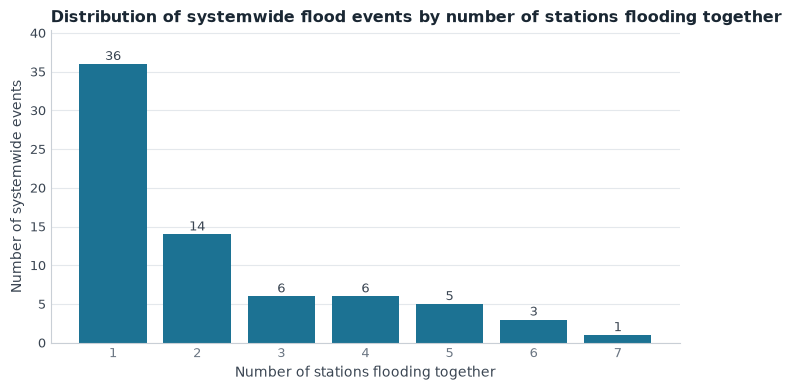

In [13]:
counts = system_events_mod["n_stations"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(counts.index.astype(str), counts.values, color=C_MAIN)
for x, v in enumerate(counts.values):
    ax.text(x, v + 0.5, str(v), ha="center", fontsize=9, color=BODY)
ax.set_xlabel("Number of stations flooding together")
ax.set_ylabel("Number of systemwide events")
ax.set_ylim(0, counts.values.max() * 1.12)
ax.set_title(
    "Distribution of systemwide flood events by number of stations flooding together"
)
style_ax(ax, grid="y")
plt.tight_layout()
plt.show()

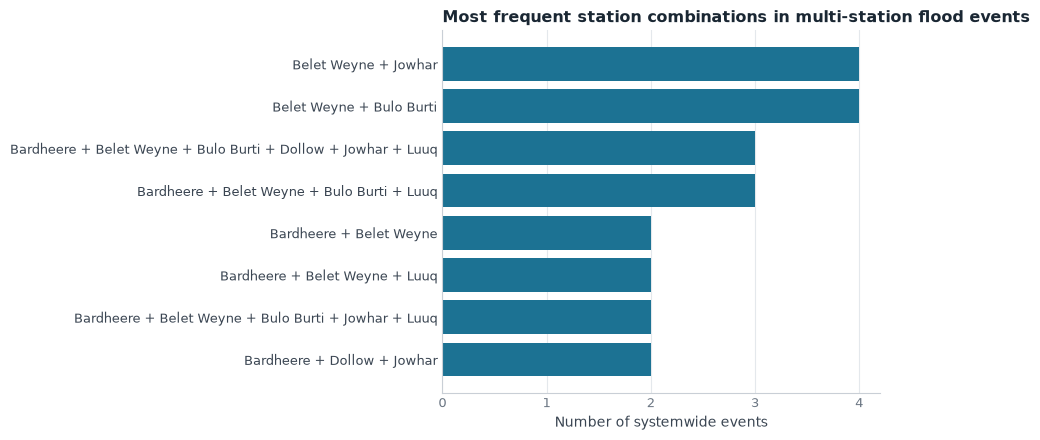

In [14]:
top_combos = (
    system_events_mod[system_events_mod["n_stations"] >= 2]["station_names"]
    .value_counts()
    .head(8)
    .sort_values()
)
short_labels = [
    c.replace(" (Shabelle)", "").replace(" (Juba)", "").replace(", ", " + ")
    for c in top_combos.index
]

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(range(len(top_combos)), top_combos.values, color=C_MAIN)
ax.set_yticks(range(len(top_combos)))
ax.set_yticklabels(short_labels, fontsize=9)
ax.set_xlabel("Number of systemwide events")
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.set_title(
    "Most frequent station combinations in multi-station flood events"
)
style_ax(ax)
plt.tight_layout()
plt.show()

And the headline version of the same split, across every systemwide event:

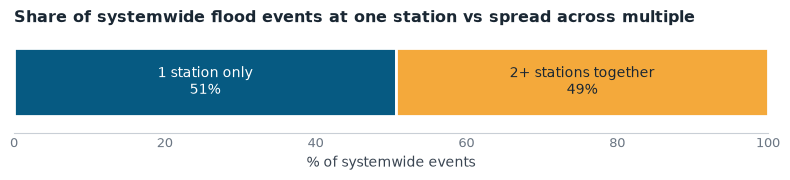

In [15]:
n_isolated_events = (system_events_mod["n_stations"] == 1).sum()
n_joint_events = (system_events_mod["n_stations"] >= 2).sum()
total = n_isolated_events + n_joint_events
pct_isolated = 100 * n_isolated_events / total
pct_joint_all = 100 * n_joint_events / total

fig, ax = plt.subplots(figsize=(8, 1.9))
ax.barh([0], [pct_isolated], color=C_ISOL, edgecolor="white", linewidth=2)
ax.barh(
    [0],
    [pct_joint_all],
    left=[pct_isolated],
    color=C_JOINT,
    edgecolor="white",
    linewidth=2,
)
ax.text(
    pct_isolated / 2,
    0,
    f"1 station only\n{pct_isolated:.0f}%",
    ha="center",
    va="center",
    color="white",
    fontsize=10,
)
ax.text(
    pct_isolated + pct_joint_all / 2,
    0,
    f"2+ stations together\n{pct_joint_all:.0f}%",
    ha="center",
    va="center",
    color=INK,
    fontsize=10,
)
ax.set_xlim(0, 100)
ax.set_ylim(-0.6, 0.6)
ax.set_yticks([])
ax.spines["left"].set_visible(False)
ax.set_xlabel("% of systemwide events")
ax.set_title(
    "Share of systemwide flood events at one station vs spread across multiple"
)
ax.tick_params(length=0)
plt.tight_layout()
plt.show()

## Isolated vs joint flood frequency per station (Moderate Flood Risk)

For each station's own events, is it flooding alone or is at least one
other station flooding within the same 14-day window? Rates use each
station's own full record length, so "joint" is a lower bound before other
gauges existed to be joint *with*.

In [16]:
rows2 = []
for sn, periods in station_events_mod.items():
    n_isolated = 0
    n_joint = 0
    for row in periods.itertuples():
        lo = row.start - pd.Timedelta(days=TOLERANCE_DAYS)
        hi = row.end + pd.Timedelta(days=TOLERANCE_DAYS)
        match = system_events_mod[
            (system_events_mod["start"] <= hi)
            & (system_events_mod["end"] >= lo)
        ]
        n_stations = match["n_stations"].max() if len(match) else 1
        if n_stations <= 1:
            n_isolated += 1
        else:
            n_joint += 1

    record_years = summary_mod.loc[sn, "record_years"]
    n_total = n_isolated + n_joint
    rows2.append(
        {
            "station_number": sn,
            "station_name": thresholds.loc[sn, "Label"],
            "n_isolated": n_isolated,
            "n_joint": n_joint,
            "isolated_per_year": n_isolated / record_years,
            "joint_per_year": n_joint / record_years,
            "pct_joint": 100 * n_joint / n_total if n_total else float("nan"),
        }
    )

isolation_summary = pd.DataFrame(rows2).set_index("station_number")
isolation_summary = isolation_summary.sort_values("pct_joint", ascending=False)

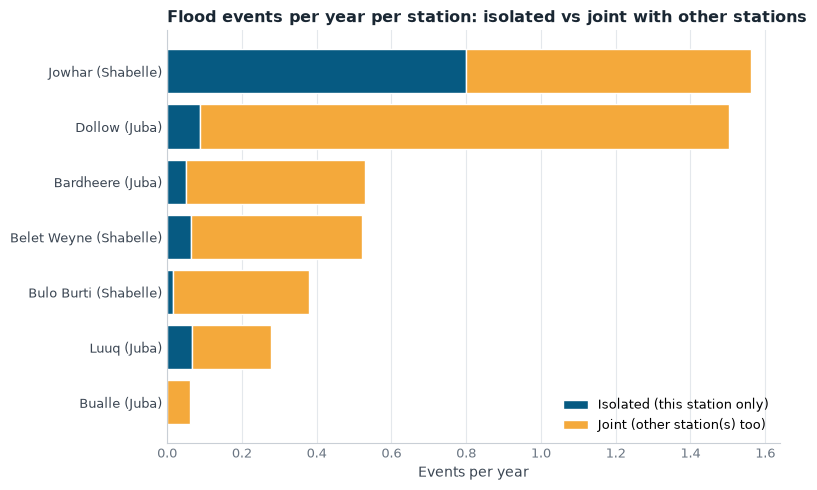

In [17]:
by_name = isolation_summary.set_index("station_name").copy()
by_name["total_per_year"] = (
    by_name["isolated_per_year"] + by_name["joint_per_year"]
)
by_name = by_name.sort_values("total_per_year")

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(
    by_name.index,
    by_name["isolated_per_year"],
    color=C_ISOL,
    edgecolor="white",
    linewidth=1,
    label="Isolated (this station only)",
)
ax.barh(
    by_name.index,
    by_name["joint_per_year"],
    left=by_name["isolated_per_year"],
    color=C_JOINT,
    edgecolor="white",
    linewidth=1,
    label="Joint (other station(s) too)",
)
ax.set_xlabel("Events per year")
ax.set_title(
    "Flood events per year per station: isolated vs joint with other stations"
)
ax.legend(loc="lower right")
style_ax(ax)
plt.tight_layout()
plt.show()

And the same isolated-vs-joint story as a single, simpler number per
station:

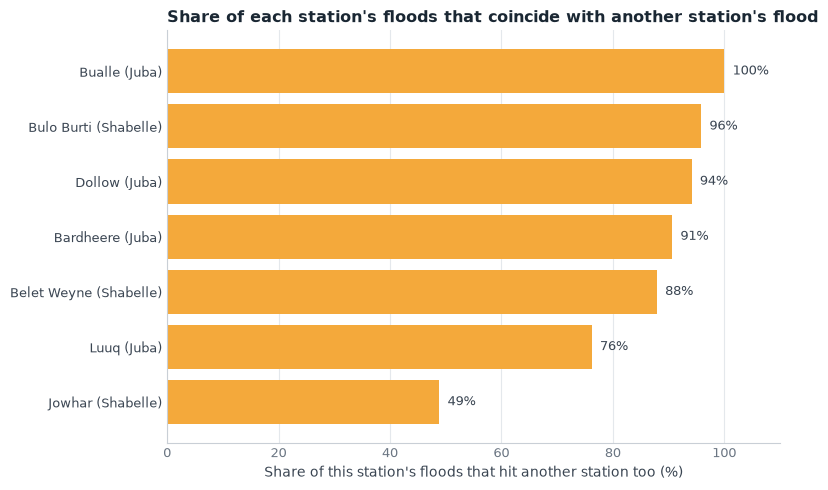

In [18]:
fig, ax = plt.subplots(figsize=(8, 5))
by_name = isolation_summary.set_index("station_name")[
    "pct_joint"
].sort_values()
ax.barh(by_name.index, by_name.values, color=C_JOINT)
for y, v in enumerate(by_name.values):
    ax.text(v + 1.5, y, f"{v:.0f}%", va="center", fontsize=9, color=BODY)
ax.set_xlabel(
    "Share of this station's floods that hit another station too (%)"
)
ax.set_xlim(0, 110)
ax.set_title(
    "Share of each station's floods that coincide with another station's flood"
)
style_ax(ax)
plt.tight_layout()
plt.show()

## Overall (systemwide) return period: Moderate vs High Risk

A systemwide flood event is defined as *any* monitored station reaching
its own threshold on a given day: the union of every station's
exceedance days, collapsed into events with the same 14-day recession rule
used per-station. Shown for the full record (using whichever stations were
reporting at the time) and for the post-2000 period, where the network is
more completely and consistently monitored.

In [19]:
def overall_return_period(exceed_dates_by_station, min_date=None):
    all_dates = sorted(
        set().union(
            *[
                d[d >= min_date] if min_date is not None else d
                for d in exceed_dates_by_station.values()
            ]
        )
    )
    all_dates = pd.DatetimeIndex(all_dates)
    events = event_periods(all_dates, min_recession_days=MIN_RECESSION_DAYS)

    record_start = max(
        min(df["level(m)"].dropna().index.min() for df in levels.values()),
        pd.Timestamp(min_date) if min_date is not None else pd.Timestamp.min,
    )
    record_end = max(
        df["level(m)"].dropna().index.max() for df in levels.values()
    )
    years_covered = (record_end - record_start).days / 365.25
    return len(events), years_covered, years_covered / len(events)


overall_rows = []
for label, exceed_dates in [("Moderate", exceed_mod), ("High", exceed_high)]:
    for period_label, min_date in [
        ("full record", None),
        ("post-2000", "2000-01-01"),
    ]:
        n, years, rp = overall_return_period(exceed_dates, min_date=min_date)
        overall_rows.append(
            {
                "threshold": label,
                "period": period_label,
                "n_events": n,
                "years_covered": years,
                "return_period_years": rp,
            }
        )

overall_rp = pd.DataFrame(overall_rows)
overall_rp

,threshold,period,n_events,years_covered,return_period_years
0,Moderate,full record,71,75.312799,1.060744
1,Moderate,post-2000,55,26.540726,0.482559
2,High,full record,46,75.312799,1.637235
3,High,post-2000,42,26.540726,0.631922


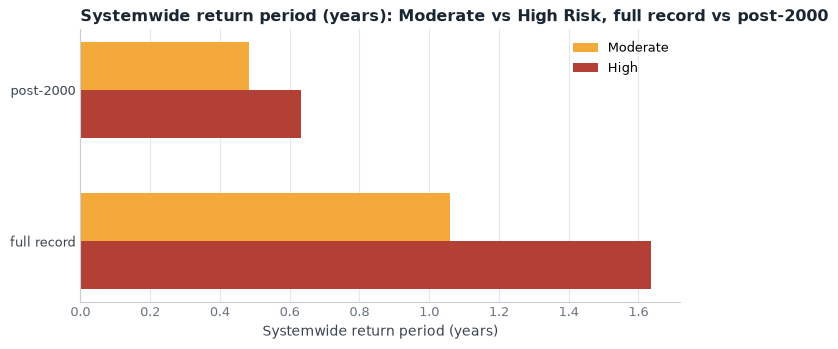

In [20]:
fig, ax = plt.subplots(figsize=(7, 3.6))
pivot = overall_rp.pivot(
    index="period", columns="threshold", values="return_period_years"
)
pivot = pivot[["Moderate", "High"]].loc[["full record", "post-2000"]]

y = np.arange(len(pivot))
height = 0.32
ax.barh(
    y + height / 2, pivot["Moderate"], height, color=C_MOD, label="Moderate"
)
ax.barh(y - height / 2, pivot["High"], height, color=C_HIGH, label="High")
ax.set_yticks(y)
ax.set_yticklabels(pivot.index)
ax.set_xlabel("Systemwide return period (years)")
ax.set_title(
    "Systemwide return period (years): Moderate vs High Risk, full record vs post-2000"
)
ax.legend(loc="upper right")
style_ax(ax)
plt.tight_layout()
plt.show()

## Takeaways

**Moderate vs High Risk frequency**

- Jowhar and Dollow reach Moderate risk almost every year (return period
  ~1.2-1.4 years) and still reach High Risk roughly once a year each
  (~1.1-1.6 years) - the two thresholds are close together at these
  stations, so "moderate" already signals a serious event there.
- Everywhere else the gap is much wider: Bualle's High Risk return period
  (~12 years) is barely longer than its unreliable Moderate estimate
  (n=1 event), while Luuq goes from ~3.7 years (Moderate) to ~8 years
  (High) and Bulo Burti from ~2.9 to ~5.8 years.
- Systemwide (any station crossing its own threshold): a Moderate-level
  event happens about once a year over the full record (rising to ~2/year
  post-2000), while a High-Risk-level event happens roughly every
  1.6 years (full record) or ~0.6 years post-2000 - High Risk is common
  enough, system-wide, to be a realistic trigger condition, not a rare
  tail event.

**Co-occurrence** (Moderate threshold - High Risk events are too sparse
per station for a reliable pairwise breakdown)

- Same-river stations co-occur strongly: within the Juba, Luuq and
  Bardheere share 87% of their events with each other; within the
  Shabelle, Belet Weyne and Bulo Burti share 61-92%.
- The signal weakens downstream: Jowhar, the most downstream Shabelle
  gauge, matches only 16-56% of its upstream neighbours' events.
- Cross-river overlap is real but weaker than within-river (roughly
  16-82%), consistent with both basins responding to the same Gu/Deyr
  rainy seasons on top of the within-river signal.
- On average 2.2 stations flood together per systemwide event; 51% of
  systemwide events involve only 1 station. The largest event on record
  (Oct-Dec 2023) hit all 7 stations at once.
- Jowhar is the outlier for isolation: only ~49% of its floods happen
  alongside another station - the rest are local events nobody else
  records. Every other station floods jointly 76-100% of the time.
- Bualle's row/column is not meaningful in any of the co-occurrence or
  return-period figures above - it has only 1 recorded Moderate event in
  total, so results built on it are a sample size of one.
- Pre-2000 data is sparse for every station (visible as the gap in the
  timeline above), likely a monitoring gap rather than an actual quiet
  period.

## The 1-in-3-year flood level, from the gauge record alone

**Fitting window: post-2000 only** (decision 2026-08-06). Activations
cluster after ~2005, so a full-record fit understates today's 1-in-3-year
level and over-fires badly; fitting on the modern regime makes the RP3
activate at the advertised rate. The full-record comparison below shows
the size of that correction. Operationally, re-fit annually on a rolling
modern window.

What observed water level corresponds to a 1-in-3-year event at each station?
Computed purely from SWALIM: per season (Gu: Mar-May | Deyr: Oct-Dec) and for
the year as a whole, take each year's maximum level and read the level at a
3-year return period off the Weibull plotting positions (log-log
interpolation between ranked maxima: the team-standard approach,
methods/return-periods.md). RP2/4/5 shown for context.

In [21]:
TARGET_RPS = [2, 3, 4, 5]
# RP levels are fitted on post-2000 data only (user decision 2026-08-06):
# activations cluster after ~2005, so a full-record fit over-fires badly in
# the modern regime (see the full-record comparison further down).
RP_FIT_FROM = 2000

rows = []
for sn, df in levels.items():
    s = df["level(m)"].dropna()
    s = s[s.index.year >= RP_FIT_FROM]
    name = thresholds.loc[sn, "Station Name"] if sn in thresholds.index else sn
    river = thresholds.loc[sn, "River"] if sn in thresholds.index else ""
    for window, months in SEASON_MONTHS.items():
        sub = s[s.index.month.isin(months)]
        am = sub.groupby(sub.index.year).max().dropna()
        row = {
            "station": name,
            "river": river,
            "code": sn,
            "window": window,
            "n_years": len(am),
        }
        for rp in TARGET_RPS:
            row[f"rp{rp}_level_m"] = round(weibull_level(am.values, rp), 2)
        rows.append(row)
rp_levels = pd.DataFrame(rows)
for col, label in [
    ("Moderate Flood Risk", "moderate_m"),
    ("High Flood Risk", "high_m"),
]:
    rp_levels[label] = rp_levels["code"].map(thresholds[col])
show = rp_levels[rp_levels.window != "any"].sort_values(
    ["river", "station", "window"]
)
show[
    [
        "station",
        "river",
        "window",
        "n_years",
        "rp2_level_m",
        "rp3_level_m",
        "rp4_level_m",
        "rp5_level_m",
        "moderate_m",
        "high_m",
    ]
].reset_index(drop=True)

,station,river,window,n_years,rp2_level_m,rp3_level_m,rp4_level_m,rp5_level_m,moderate_m,high_m
0,Bardheere,Juba,deyr,23,7.39,9.00,9.00,9.02,7.4,8.20
1,Bardheere,Juba,gu,22,6.88,7.82,8.05,8.36,7.4,8.20
2,Bualle,Juba,deyr,16,7.10,7.27,7.35,7.39,9.0,10.00
3,Bualle,Juba,gu,17,6.03,6.41,7.09,7.31,9.0,10.00
4,Dollow,Juba,deyr,10,5.05,5.09,5.19,5.43,4.5,5.00
5,Dollow,Juba,gu,12,4.06,5.27,5.43,5.51,4.5,5.00
6,Kaitoi,Juba,deyr,0,NaN,NaN,NaN,NaN,NaN,NaN
7,Kaitoi,Juba,gu,0,NaN,NaN,NaN,NaN,NaN,NaN
8,Luuq,Juba,deyr,25,4.90,5.34,5.64,5.83,5.5,6.00
9,Luuq,Juba,gu,25,4.48,5.23,5.44,5.62,5.5,6.00


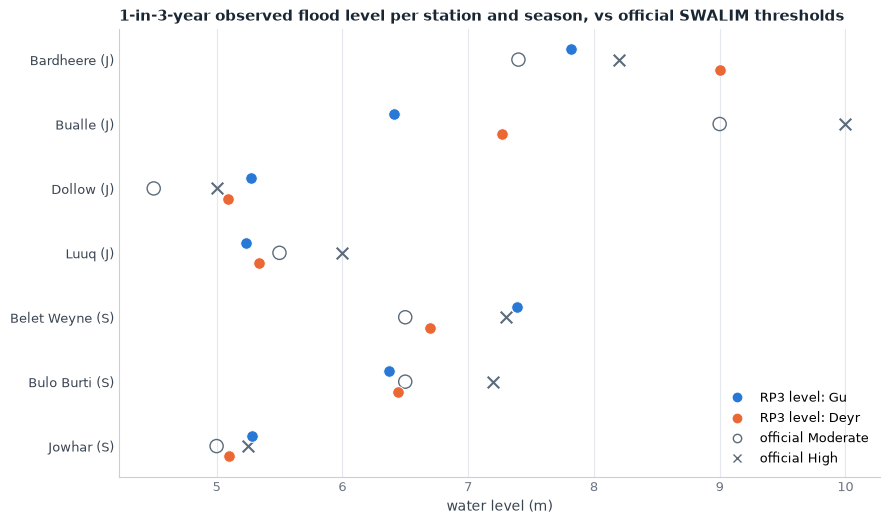

In [22]:
plot_df = rp_levels[
    (rp_levels.window != "any") & rp_levels.rp3_level_m.notna()
].copy()
plot_df["label"] = plot_df["station"] + " (" + plot_df["river"].str[0] + ")"
order = plot_df.sort_values(["river", "station"]).label.unique()
ypos = {l: i for i, l in enumerate(order)}
fig, ax = plt.subplots(figsize=(9, 0.55 * len(order) + 1.5))
W_COLORS = {"gu": C_GU, "deyr": C_DEYR}
for _, r in plot_df.iterrows():
    y = ypos[r.label]
    off = -0.16 if r.window == "gu" else 0.16
    ax.scatter(
        r.rp3_level_m,
        y + off,
        color=W_COLORS[r.window],
        s=70,
        zorder=5,
        edgecolors="white",
        linewidths=0.7,
        label=None,
    )
for _, r in plot_df.drop_duplicates("label").iterrows():
    y = ypos[r.label]
    if not np.isnan(r.moderate_m):
        ax.scatter(
            r.moderate_m,
            y,
            marker="o",
            facecolors="none",
            edgecolors=C_REF,
            s=90,
            zorder=4,
        )
    if not np.isnan(r.high_m):
        ax.scatter(r.high_m, y, marker="x", color=C_REF, s=70, zorder=4)
ax.set_yticks(range(len(order)))
ax.set_yticklabels(order, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("water level (m)")
handles = [
    plt.Line2D([], [], color=C_GU, marker="o", ls="", label="RP3 level: Gu"),
    plt.Line2D(
        [], [], color=C_DEYR, marker="o", ls="", label="RP3 level: Deyr"
    ),
    plt.Line2D(
        [],
        [],
        color=C_REF,
        marker="o",
        markerfacecolor="none",
        ls="",
        label="official Moderate",
    ),
    plt.Line2D([], [], color=C_REF, marker="x", ls="", label="official High"),
]
ax.legend(handles=handles, loc="lower right")
ax.set_title(
    "1-in-3-year observed flood level per station and season, vs official SWALIM thresholds",
    fontsize=11,
)
style_ax(ax)
plt.tight_layout()

**How to read it:** where the RP3 dot sits above the official Moderate
circle, a moderate-threshold trigger would fire more often than 1-in-3
years at that station (and vice versa). The spread between Gu and Deyr dots
at one station shows how differently the two seasons behave: a single
all-year threshold would mis-state the frequency of both.

## Where the 1-in-3-year level sits between the official risk levels

Per station: the band from Moderate to High Flood Risk (grey), Bank Full
(dark tick), and the RP3 level per season (dots). The position metric reads:
0% = exactly at Moderate | 100% = exactly at High | negative = below
Moderate | above 100% = beyond High.

In [23]:
band = rp_levels[(rp_levels.window != "any")].copy()
band = band[
    band.moderate_m.notna() & band.high_m.notna() & band.rp3_level_m.notna()
]
band["position_pct"] = (
    (
        (band.rp3_level_m - band.moderate_m)
        / (band.high_m - band.moderate_m)
        * 100
    )
    .round(0)
    .astype(int)
)
band["bankfull_m"] = band["code"].map(thresholds["Bank Full"])
show_band = band.sort_values(["river", "station", "window"])[
    [
        "station",
        "river",
        "window",
        "rp3_level_m",
        "moderate_m",
        "high_m",
        "bankfull_m",
        "position_pct",
    ]
]
show_band.reset_index(drop=True)

,station,river,window,rp3_level_m,moderate_m,high_m,bankfull_m,position_pct
0,Bardheere,Juba,deyr,9.00,7.4,8.20,10.4,200
1,Bardheere,Juba,gu,7.82,7.4,8.20,10.4,53
2,Bualle,Juba,deyr,7.27,9.0,10.00,12.0,-173
3,Bualle,Juba,gu,6.41,9.0,10.00,12.0,-259
4,Dollow,Juba,deyr,5.09,4.5,5.00,6.0,118
5,Dollow,Juba,gu,5.27,4.5,5.00,6.0,154
6,Luuq,Juba,deyr,5.34,5.5,6.00,7.0,-32
7,Luuq,Juba,gu,5.23,5.5,6.00,7.0,-54
8,Belet Weyne,Shabelle,deyr,6.70,6.5,7.30,8.3,25
9,Belet Weyne,Shabelle,gu,7.39,6.5,7.30,8.3,111


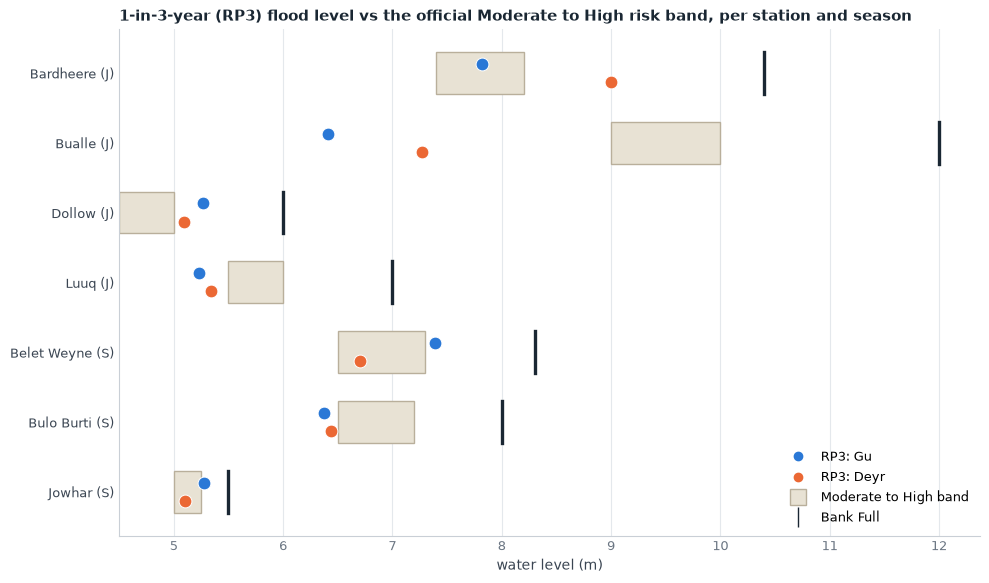

In [24]:
stations_b = band.drop_duplicates("station").sort_values(["river", "station"])
ypos = {st: i for i, st in enumerate(stations_b.station)}
fig, ax = plt.subplots(figsize=(10, 0.62 * len(ypos) + 1.6))
W_COLORS = {"gu": C_GU, "deyr": C_DEYR}
for _, r in stations_b.iterrows():
    y = ypos[r.station]
    ax.barh(
        y,
        r.high_m - r.moderate_m,
        left=r.moderate_m,
        height=0.6,
        color=C_BAND,
        edgecolor=C_BAND_EDGE,
        linewidth=1.0,
        zorder=2,
    )
    if not np.isnan(r.bankfull_m):
        ax.plot(
            [r.bankfull_m, r.bankfull_m],
            [y - 0.3, y + 0.3],
            color=INK,
            lw=2.4,
            zorder=3,
        )
for _, r in band.iterrows():
    y = ypos[r.station] + (-0.13 if r.window == "gu" else 0.13)
    ax.scatter(
        r.rp3_level_m,
        y,
        color=W_COLORS[r.window],
        s=85,
        zorder=5,
        edgecolors="white",
        linewidths=0.7,
    )
labels_b = [f"{r.station} ({r.river[0]})" for _, r in stations_b.iterrows()]
ax.set_yticks(range(len(ypos)))
ax.set_yticklabels(labels_b, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("water level (m)")
handles = [
    plt.Line2D([], [], color=C_GU, marker="o", ls="", label="RP3: Gu"),
    plt.Line2D([], [], color=C_DEYR, marker="o", ls="", label="RP3: Deyr"),
    plt.Line2D(
        [],
        [],
        color=C_BAND,
        marker="s",
        ls="",
        markersize=12,
        markeredgecolor=C_BAND_EDGE,
        label="Moderate to High band",
    ),
    plt.Line2D(
        [], [], color=INK, marker="|", ls="", markersize=14, label="Bank Full"
    ),
]
ax.legend(handles=handles, loc="lower right")
ax.set_title(
    "1-in-3-year (RP3) flood level vs the official Moderate to High risk band, per station and season",
    fontsize=11,
)
style_ax(ax)
plt.tight_layout()

### How often is each level actually crossed, per season?

For every station and season window: the share of season-years whose peak
level reaches the seasonal RP3, the official Moderate, and the official High
mark. RP3 sits near 33% by construction (it is fitted to these same maxima),
so it acts as the 1-in-3 reference line: bars left of it are rarer than
1-in-3, bars right of it are more frequent.


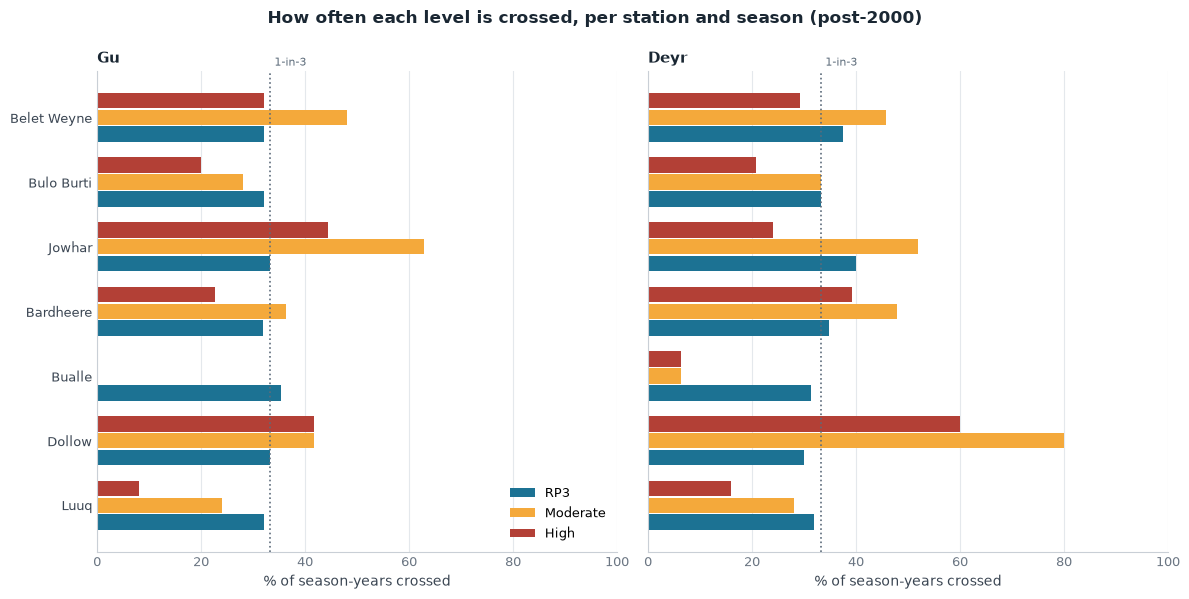

In [25]:
rows_x = []
for _, r in rp_levels[rp_levels.window != "any"].iterrows():
    s = levels[r.code]["level(m)"].dropna()
    sub = s[s.index.month.isin(SEASON_MONTHS[r.window])]
    am = sub.groupby(sub.index.year).max().dropna()
    am = am[am.index >= 2000]  # evaluate on the same era the RPs are fitted to
    if len(am) < 8:
        continue
    for tname, thr in [
        ("RP3", r.rp3_level_m),
        ("Moderate", r.moderate_m),
        ("High", r.high_m),
    ]:
        if pd.isna(thr):
            continue
        rows_x.append(
            {
                "station": r.station,
                "river": r.river,
                "window": r.window,
                "threshold": tname,
                "n_years": len(am),
                "pct_seasons": 100 * (am.values >= thr).mean(),
            }
        )
xing = pd.DataFrame(rows_x)

T_COLORS = {"RP3": C_MAIN, "Moderate": C_MOD, "High": C_HIGH}
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
order = (
    xing.drop_duplicates("station")
    .sort_values(["river", "station"], ascending=[True, False])
    .station.tolist()
)
ypos = {st: i for i, st in enumerate(order)}
for ax, window in zip(axes, ["gu", "deyr"]):
    sub = xing[xing.window == window]
    for k, (tname, color) in enumerate(T_COLORS.items()):
        tsub = sub[sub.threshold == tname].set_index("station")
        ys = [ypos[st] + (k - 1) * 0.26 for st in tsub.index]
        ax.barh(ys, tsub.pct_seasons, height=0.24, color=color, label=tname)
    ax.axvline(100 / 3, color=C_REF, ls=":", lw=1.2)
    ax.text(100 / 3, len(order) - 0.2, " 1-in-3", fontsize=8, color=C_REF)
    ax.set_yticks(range(len(order)))
    ax.set_yticklabels(order, fontsize=9)
    ax.set_xlim(0, 100)
    ax.set_xlabel("% of season-years crossed")
    ax.set_title(f"{window.capitalize()}", fontsize=11)
    style_ax(ax)
axes[0].legend(loc="lower right")
fig.suptitle(
    "How often each level is crossed, per station and season (post-2000)",
    fontweight="bold",
    color=INK,
    fontsize=12,
    y=0.99,
)
plt.tight_layout()

In [26]:
xing.pivot_table(
    index=["river", "station"],
    columns=["window", "threshold"],
    values="pct_seasons",
).round(0)

window                deyr                   gu               
threshold             High Moderate   RP3  High Moderate   RP3
river    station                                              
Juba     Bardheere    39.0     48.0  35.0  23.0     36.0  32.0
         Bualle        6.0      6.0  31.0   0.0      0.0  35.0
         Dollow       60.0     80.0  30.0  42.0     42.0  33.0
         Luuq         16.0     28.0  32.0   8.0     24.0  32.0
Shabelle Belet Weyne  29.0     46.0  38.0  32.0     48.0  32.0
         Bulo Burti   21.0     33.0  33.0  20.0     28.0  32.0
         Jowhar       24.0     52.0  40.0  44.0     63.0  33.0

### The levels on the hydrograph

Water levels against time with the three lines drawn in: official Moderate,
official High, and the seasonal RP3 (Gu and Deyr fitted separately, so two
dotted lines). This is the raw picture the frequencies above summarize.


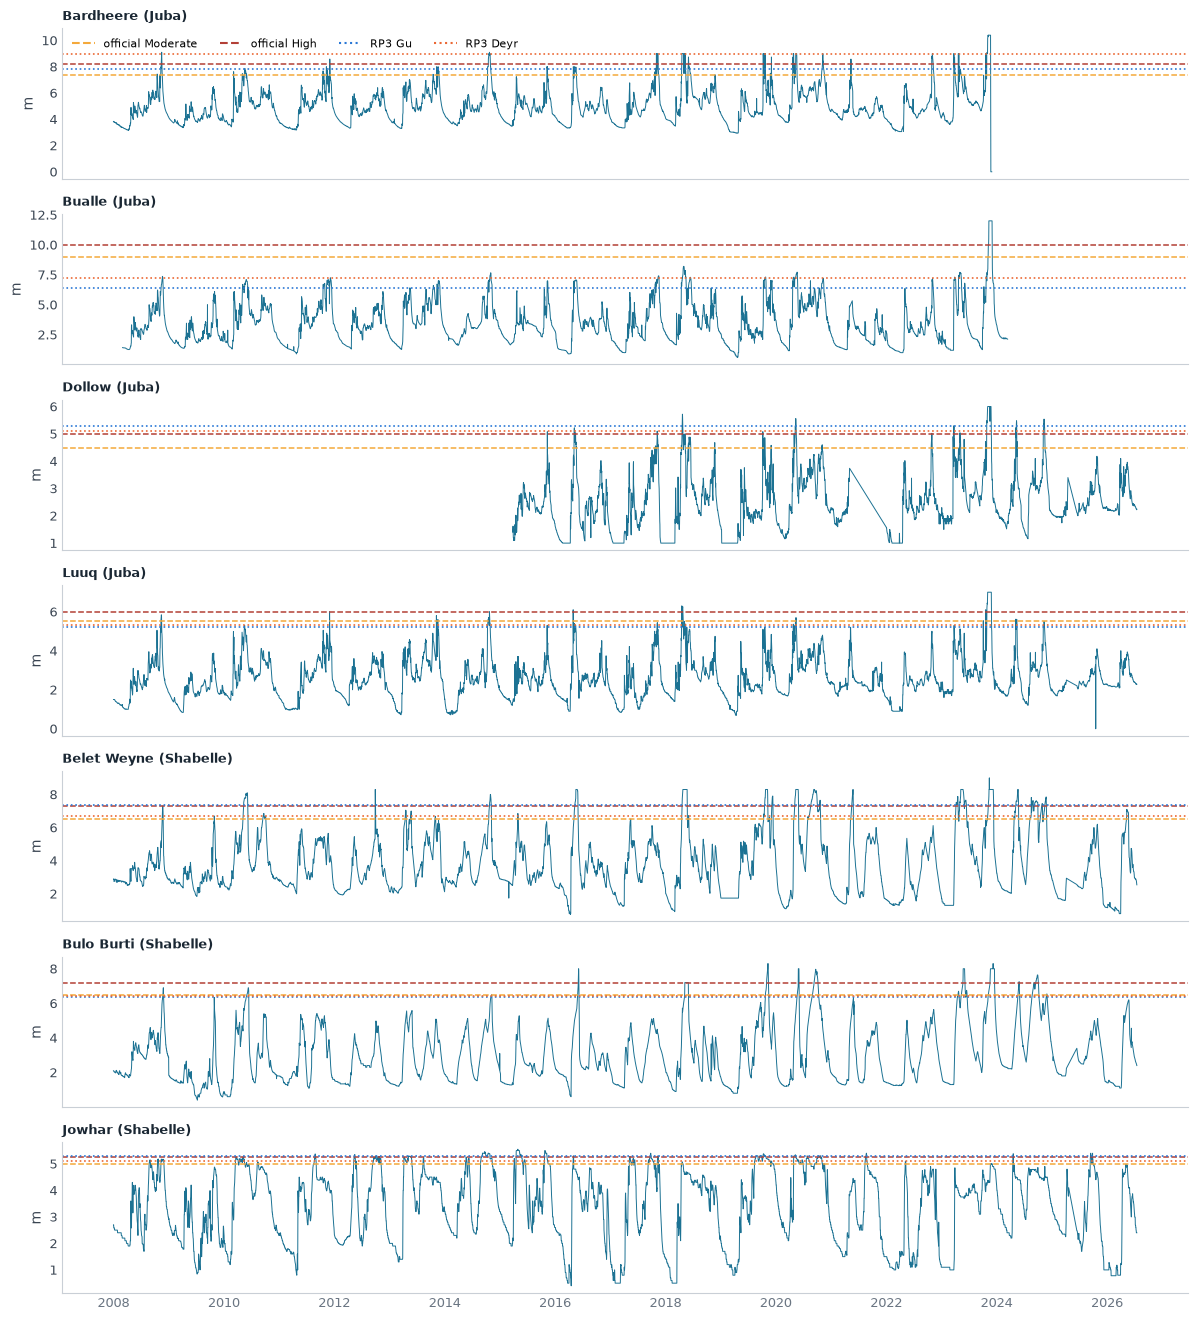

In [27]:
PLOT_FROM = "2008-01-01"
hydro_codes = (
    rp_levels[(rp_levels.window != "any") & rp_levels.moderate_m.notna()]
    .drop_duplicates("code")
    .sort_values(["river", "station"])
)
fig, axes = plt.subplots(
    len(hydro_codes), 1, figsize=(12, 1.9 * len(hydro_codes)), sharex=True
)
for ax, (_, r) in zip(np.atleast_1d(axes), hydro_codes.iterrows()):
    s = levels[r.code]["level(m)"].dropna().loc[PLOT_FROM:]
    ax.plot(s.index, s.values, color=C_MAIN, lw=0.7)
    ax.axhline(r.moderate_m, color=C_MOD, ls="--", lw=1.1)
    ax.axhline(r.high_m, color=C_HIGH, ls="--", lw=1.1)
    rp3s = rp_levels[(rp_levels.code == r.code) & (rp_levels.window != "any")]
    for _, rr in rp3s.iterrows():
        if not pd.isna(rr.rp3_level_m):
            ax.axhline(
                rr.rp3_level_m,
                color=C_GU if rr.window == "gu" else C_DEYR,
                ls=":",
                lw=1.2,
            )
    ax.set_ylabel("m")
    ax.set_title(f"{r.station} ({r.river})", fontsize=9.5)
    style_ax(ax, grid=None)
handles = [
    plt.Line2D([], [], color=C_MOD, ls="--", label="official Moderate"),
    plt.Line2D([], [], color=C_HIGH, ls="--", label="official High"),
    plt.Line2D([], [], color=C_GU, ls=":", label="RP3 Gu"),
    plt.Line2D([], [], color=C_DEYR, ls=":", label="RP3 Deyr"),
]
np.atleast_1d(axes)[0].legend(
    handles=handles, loc="upper left", ncol=4, fontsize=8
)
plt.tight_layout()

### How many distinct crossings per season?

A season can flood more than once: this counts **distinct crossings of the
official Moderate Flood Risk level** per season-year, where a new crossing
requires the level to first stay below the mark for more than 14 days (the
same recession rule used for events throughout). Blank cells = no gauge
record.


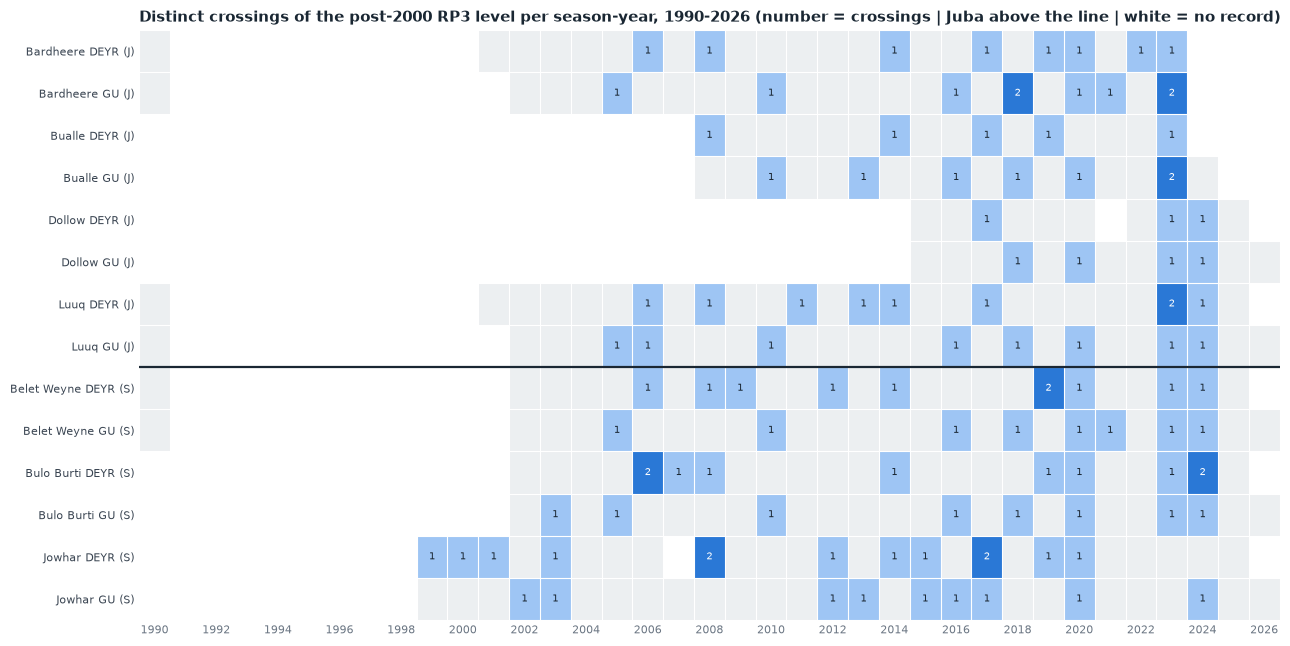

In [28]:
count_rows = []
for _, r in rp_levels[rp_levels.window != "any"].iterrows():
    if pd.isna(r.rp3_level_m) or pd.isna(r.moderate_m):
        continue
    s = levels[r.code]["level(m)"].dropna()
    sub = s[s.index.month.isin(SEASON_MONTHS[r.window])]
    if not len(sub):
        continue
    exceed = sub[sub >= r.rp3_level_m]
    evp = event_periods(exceed.index, min_recession_days=14)
    counts = (
        evp.groupby(evp["start"].dt.year).size()
        if len(evp)
        else pd.Series(dtype=int)
    )
    for y in sorted(set(sub.index.year)):
        count_rows.append(
            {
                "station": r.station,
                "river": r.river,
                "window": r.window,
                "year": int(y),
                "n_crossings": int(counts.get(y, 0)),
            }
        )
xc = pd.DataFrame(count_rows)

import matplotlib.colors as mcolors

Y0, Y1 = 1990, 2026
years = list(range(Y0, Y1 + 1))
plot = xc[(xc.year >= Y0)].copy()
plot["label"] = (
    plot.station
    + " "
    + plot.window.str.upper()
    + " ("
    + plot.river.str[0]
    + ")"
)
order = sorted(plot.label.unique(), key=lambda l: ("(S)" in l, l))
mat = []
for lab in order:
    sub = plot[plot.label == lab].set_index("year")["n_crossings"]
    mat.append([sub.get(y, -1) for y in years])
cmap = mcolors.ListedColormap(
    ["#FFFFFF", "#ECEFF1", "#9EC5F4", "#2A78D6", "#0D366B"]
)
norm = mcolors.BoundaryNorm([-1.5, -0.5, 0.5, 1.5, 2.5, 99], cmap.N)
fig, ax = plt.subplots(figsize=(13, 0.34 * len(order) + 1.8))
ax.imshow(mat, cmap=cmap, norm=norm, aspect="auto")
for i, row in enumerate(mat):
    for j, v in enumerate(row):
        if v >= 1:
            ax.text(
                j,
                i,
                str(int(v)),
                ha="center",
                va="center",
                fontsize=7,
                color="white" if v >= 2 else INK,
            )
ax.set_xticks(range(0, len(years), 2))
ax.set_xticklabels(years[::2], fontsize=8)
ax.set_yticks(range(len(order)))
ax.set_yticklabels(order, fontsize=8)
ax.set_xticks([x - 0.5 for x in range(len(years) + 1)], minor=True)
ax.set_yticks([y - 0.5 for y in range(len(order) + 1)], minor=True)
ax.grid(which="minor", color="white", linewidth=0.8)
ax.tick_params(which="both", length=0)
for sp in ax.spines.values():
    sp.set_visible(False)
n_juba = sum(1 for l in order if l.endswith("(J)"))
ax.axhline(n_juba - 0.5, color=INK, lw=1.6)
ax.set_title(
    f"Distinct crossings of the post-2000 RP3 level per season-year, {Y0}-{Y1} "
    "(number = crossings | Juba above the line | white = no record)",
    fontsize=11,
)
plt.tight_layout()

In [29]:
xc[xc.year == 2023].pivot_table(
    index=["river", "station"], columns="window", values="n_crossings"
).astype(int)

window                deyr  gu
river    station              
Juba     Bardheere       1   2
         Bualle          1   2
         Dollow          1   1
         Luuq            2   1
Shabelle Belet Weyne     1   1
         Bulo Burti      1   1
         Jowhar          0   0

## When would a trigger have activated? Moderate vs post-2000 RP3

The **operative baseline is the computed post-2000 RP3** (decision
2026-08-26): it is frequency-calibrated, so it means the same thing at
every station, where the official marks do not. The official Moderate
crossings stay in the comparison below to show the difference:

- **Official Moderate level**: the impact-severity mark. Its crossing rate
  varies wildly by station (most years at Jowhar | roughly every other year
  at Belet Weyne | almost never at Bualle), so it is not a fixed-rarity
  trigger.
- **Post-2000 RP3**: frequency-calibrated to ~1-in-3 seasons by
  construction, so its activation budget is comparable across stations.

The heatmap overlays them: dark blue = a season that crossed both | amber =
Moderate only (officially flagged but not 1-in-3 rare there) | teal = RP3
only (statistically rare but below the official mark, e.g. Bualle where
Moderate sits at an unreachable 9 m). The rate columns in the table make
the frequency contrast explicit. The exposure comparison below keeps the
Moderate definition (matching notebooks 02-03).


In [30]:
act_rows = []
# Two event definitions, both on post-2000 data: the official Moderate level
# (impact-severity mark, frequency varies by station) and the post-2000 RP3
# (frequency-calibrated to ~1-in-3). activation_years keeps the Moderate
# convention used by the exposure comparison below; rp3_years sits alongside.
for sn, df in levels.items():
    s = df["level(m)"].dropna()
    s = s[s.index.year >= RP_FIT_FROM]
    name = thresholds.loc[sn, "Station Name"] if sn in thresholds.index else sn
    river = thresholds.loc[sn, "River"] if sn in thresholds.index else ""
    for window in ["gu", "deyr"]:
        months = SEASON_MONTHS[window]
        lev = rp_levels[(rp_levels.code == sn) & (rp_levels.window == window)]
        if not len(lev):
            continue
        mod = lev.moderate_m.iloc[0]
        rp3 = lev.rp3_level_m.iloc[0]
        if pd.isna(mod) and pd.isna(rp3):
            continue
        sub = s[s.index.month.isin(months)]
        mx = sub.groupby(sub.index.year).max().dropna()
        if not len(mx):
            continue
        mod_years = (
            sorted(mx[mx >= mod].index.tolist()) if not pd.isna(mod) else []
        )
        rp3_years = (
            sorted(mx[mx >= rp3].index.tolist()) if not pd.isna(rp3) else []
        )
        n_seasons = len(mx)
        act_rows.append(
            {
                "station": name,
                "river": river,
                "window": window,
                "moderate_m": mod,
                "rp3_post2000_m": rp3,
                "record": f"{mx.index.min()}-{mx.index.max()}",
                "n_seasons": n_seasons,
                "n_moderate": len(mod_years),
                "n_rp3": len(rp3_years),
                "activation_years": rp3_years,
                "moderate_years": mod_years,
            }
        )
act = (
    pd.DataFrame(act_rows)
    .sort_values(["river", "station", "window"])
    .reset_index(drop=True)
)
act["moderate_rate"] = (act.n_moderate / act.n_seasons).round(2)
act["rp3_rate"] = (act.n_rp3 / act.n_seasons).round(2)
act[
    [
        "station",
        "river",
        "window",
        "moderate_m",
        "rp3_post2000_m",
        "record",
        "n_seasons",
        "n_moderate",
        "moderate_rate",
        "n_rp3",
        "rp3_rate",
    ]
]

,station,river,window,moderate_m,rp3_post2000_m,record,n_seasons,n_moderate,moderate_rate,n_rp3,rp3_rate
0,Bardheere,Juba,deyr,7.4,9.00,2001-2023,23,11,0.48,8,0.35
1,Bardheere,Juba,gu,7.4,7.82,2002-2023,22,8,0.36,7,0.32
2,Bualle,Juba,deyr,9.0,7.27,2008-2023,16,1,0.06,5,0.31
3,Bualle,Juba,gu,9.0,6.41,2008-2024,17,0,0.00,6,0.35
4,Dollow,Juba,deyr,4.5,5.09,2015-2025,10,8,0.80,3,0.30
5,Dollow,Juba,gu,4.5,5.27,2015-2026,12,5,0.42,4,0.33
6,Luuq,Juba,deyr,5.5,5.34,2001-2025,25,7,0.28,8,0.32
7,Luuq,Juba,gu,5.5,5.23,2002-2026,25,6,0.24,8,0.32
8,Belet Weyne,Shabelle,deyr,6.5,6.70,2002-2025,24,11,0.46,9,0.38
9,Belet Weyne,Shabelle,gu,6.5,7.39,2002-2026,25,12,0.48,8,0.32


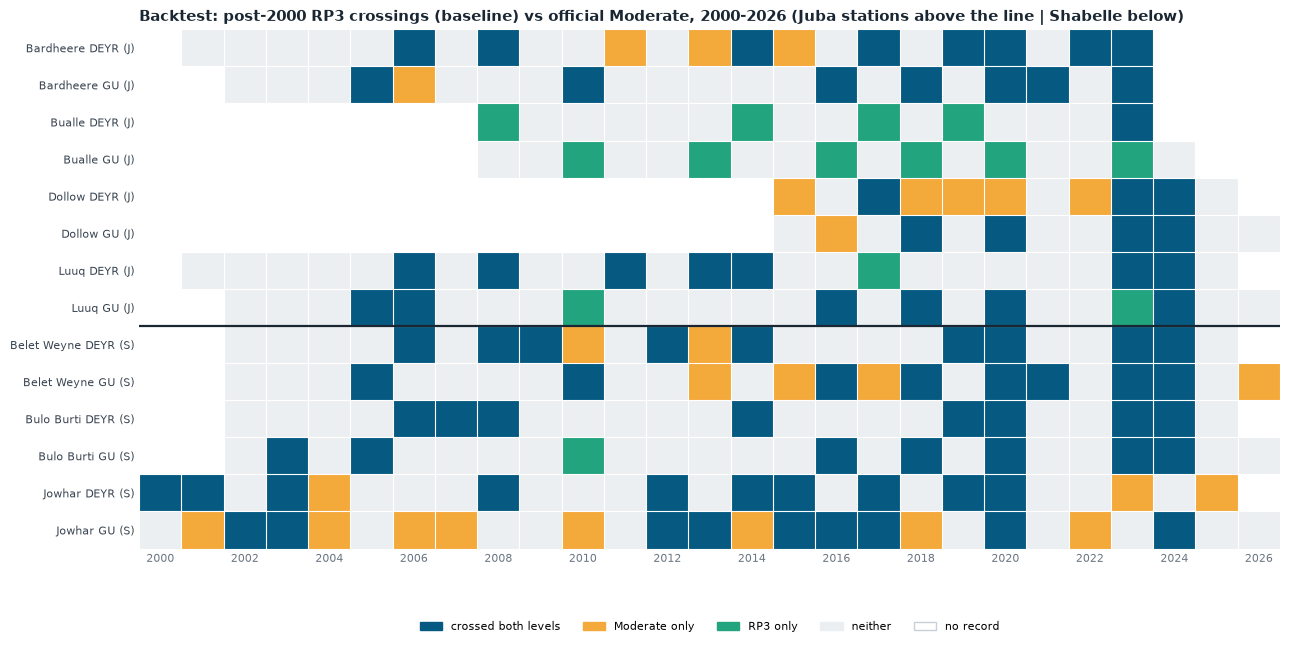

In [31]:
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches

Y0, Y1 = 2000, 2026
years = list(range(Y0, Y1 + 1))
plot = act[act.moderate_m.notna() & act.rp3_post2000_m.notna()].copy()
plot["label"] = (
    plot["station"]
    + " "
    + plot["window"].str.upper()
    + " ("
    + plot["river"].str[0]
    + ")"
)
plot = plot.sort_values(["river", "station", "window"])
mat, labels = [], []
for _, r in plot.iterrows():
    rec0, rec1 = [int(x) for x in r.record.split("-")]
    rp3_y, mod_y = set(r.activation_years), set(r.moderate_years)
    row = []
    for y in years:
        if y < rec0 or y > rec1:
            row.append(0)  # no record
        elif y in mod_y and y in rp3_y:
            row.append(4)  # crossed both levels
        elif y in mod_y:
            row.append(3)  # Moderate only
        elif y in rp3_y:
            row.append(2)  # RP3 only (RP3 below the official Moderate)
        else:
            row.append(1)  # neither
    mat.append(row)
    labels.append(r.label)
cmap = mcolors.ListedColormap(
    ["#FFFFFF", "#ECEFF1", "#22A47F", "#F4A93B", "#065A82"]
)
fig, ax = plt.subplots(figsize=(13, 0.34 * len(labels) + 1.8))
ax.imshow(mat, cmap=cmap, vmin=0, vmax=4, aspect="auto")
ax.set_xticks(range(0, len(years), 2))
ax.set_xticklabels(years[::2], fontsize=8)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=8)
ax.set_xticks([x - 0.5 for x in range(len(years) + 1)], minor=True)
ax.set_yticks([y - 0.5 for y in range(len(labels) + 1)], minor=True)
ax.grid(which="minor", color="white", linewidth=0.8)
ax.tick_params(which="both", length=0)
for sp in ax.spines.values():
    sp.set_visible(False)
n_juba = (plot.river == "Juba").sum()
ax.axhline(n_juba - 0.5, color=INK, lw=1.6)
ax.legend(
    handles=[
        mpatches.Patch(color="#065A82", label="crossed both levels"),
        mpatches.Patch(color="#F4A93B", label="Moderate only"),
        mpatches.Patch(color="#22A47F", label="RP3 only"),
        mpatches.Patch(color="#ECEFF1", label="neither"),
        mpatches.Patch(
            facecolor="#FFFFFF", edgecolor="#C9CFD6", label="no record"
        ),
    ],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=5,
    fontsize=8,
)
ax.set_title(
    f"Backtest: post-2000 RP3 crossings (baseline) vs official Moderate, {Y0}-{Y1} "
    f"(Juba stations above the line | Shabelle below)",
    fontsize=11,
)
plt.tight_layout()

**How to read it:** columns that light up across many rows are basin-wide
floods (1997/98 El Nino is left of most records' start | Deyr 2006 | Gu 2018
| Deyr 2019 | 2023 | Gu 2024). Isolated cells are local or data-quality
events. Where a station's Gu and Deyr rows both activate in one year, both
seasons flooded (2006, 2020, 2023). The union across rows fires most years:
which is exactly why the mechanism design splits windows per river and
season rather than pooling everything into one trigger.

**Nonstationarity warning:** activations cluster heavily after ~2005 on the long-record stations (Belet Weyne, Bulo Burti, Luuq, Bardheere): an RP3 level fitted over 50+ years fires much more often than 1-in-3 in the recent period. Whether that reflects a wetter regime, upstream land-use change, or gauge datum drift, a trigger calibrated on the full record will over-fire today: fit thresholds on the modern record (post-2000) before operational use.

## Do the trigger years match actual flood exposure?

**What is being compared:** two yearly flags per river and season window:

- **Trigger years:** seasons whose peak crossed the gauge's **official
  Moderate level** (the backtest above), on post-2000 data. The heatmap below shows
  every gauged station (each compared against its own river's exposure
  series), with the reference gauges (Belet Weyne for the Shabelle | Luuq
  for the Juba) in bold; the agreement table underneath summarizes the
  reference gauges only.
- **High-impact years:** seasons in the top third of peak population exposed
  to flooding. Exposure = FloodScan flooded fraction x WorldPop population,
  computed daily per district by the team's floodexposure pipeline
  (`app.floodscan_exposure`, 1998-present), summed here over the districts
  that intersect that river's 10 km buffer, then reduced to one peak value
  per season-year.

**In the chart:** teal = the gauge trigger fired in a season that was
genuinely high-impact downstream | amber = trigger fired but exposure was
not top-third (possible false alarm, or impact missed by FloodScan) | red =
high exposure with no trigger (miss) | grey = neither.

Method details: Gu exposure window is Mar-Jun (extended to June because
exposure peaks lag the gauge crossing as water spreads) | Deyr is Oct-Dec |
seasons are ranked Weibull-style and the top third (RP >= 3) flagged as
high-impact. Caveat: exposure is an impact proxy (not displacement or
needs), and it is itself FloodScan-derived: agreement validates
gauge-vs-population consistency, not FloodScan itself.


In [32]:
eng = stratus.get_engine(stage="prod")
adm2 = stratus.codab.load_codab_from_blob("som", admin_level=2)
_raw = stratus.load_blob_data(
    "ds-aa-som-floods/processed/workflow/som_river_buffers.gpkg", stage="dev"
)
_tmp = os.path.join(tempfile.gettempdir(), "som_river_buffers.gpkg")
open(_tmp, "wb").write(_raw)
bufs = gpd.read_file(_tmp)

river_districts = {}
for _, b in bufs.iterrows():
    hit = adm2[adm2.geometry.intersects(b.geometry)]
    river_districts[b.river] = dict(zip(hit["ADM2_PCODE"], hit["ADM2_EN"]))
for r, d in river_districts.items():
    print(f"{r}: {len(d)} districts | {sorted(d.values())}")

shabelle: 15 districts | ['Afgooye', 'Afmadow', 'Balcad', 'Baraawe', 'Belet Weyne', 'Bulo Burto', 'Jalalaqsi', 'Jamaame', 'Jilib', 'Jowhar', 'Kismaayo', 'Kurtunwaarey', 'Marka', 'Qoryooley', 'Sablaale']
juba: 11 districts | ['Afmadow', 'Baardheere', "Bu'aale", 'Doolow', 'Garbahaarey', 'Jamaame', 'Jilib', 'Kismaayo', 'Luuq', 'Qansax Dheere', 'Saakow']


In [33]:
all_pcodes = sorted(set().union(*[set(d) for d in river_districts.values()]))
q = f"""SELECT valid_date, pcode, sum FROM app.floodscan_exposure
        WHERE iso3='SOM' AND adm_level='2'
        AND pcode IN ({','.join(f"'{p}'" for p in all_pcodes)})"""
exp = pd.read_sql(q, eng)
exp["valid_date"] = pd.to_datetime(exp["valid_date"])
print(
    f"{len(exp):,} rows | {exp.pcode.nunique()} districts | {exp.valid_date.min().date()} to {exp.valid_date.max().date()}"
)

229,922 rows | 22 districts | 1998-01-12 to 2026-08-25


In [34]:
# exposure lags the gauge crossing as water spreads: Gu window extended to June

exp_events = {}
exp_series = {}
for river, dset in river_districts.items():
    sub = exp[exp.pcode.isin(dset)]
    daily = sub.groupby("valid_date")["sum"].sum()
    for season, months in EXP_SEASONS.items():
        ss = daily[daily.index.month.isin(months)]
        am = ss.groupby(ss.index.year).max().dropna()
        if season == "deyr":
            am = am[am.index <= 2025]
        rp = (len(am) + 1) / am.rank(ascending=False)
        exp_events[(river, season)] = set(rp[rp >= 3].index)
        exp_series[(river, season)] = am
        print(
            f"{river} {season}: exposure-event years (top third): {sorted(exp_events[(river, season)])}"
        )

shabelle gu: exposure-event years (top third): [2002, 2004, 2006, 2009, 2010, 2017, 2018, 2023, 2025, 2026]
shabelle deyr: exposure-event years (top third): [2004, 2011, 2012, 2014, 2015, 2016, 2017, 2022, 2023]
juba gu: exposure-event years (top third): [2001, 2002, 2006, 2016, 2017, 2018, 2020, 2023, 2024, 2026]
juba deyr: exposure-event years (top third): [2000, 2002, 2004, 2006, 2011, 2014, 2017, 2023, 2024]


In [35]:
REF = {"shabelle": "Belet Weyne", "juba": "Luuq"}
rows = []
for river, gname in REF.items():
    for season in ["gu", "deyr"]:
        trig = act[(act.station == gname) & (act.window == season)]
        if not len(trig):
            continue
        tyears = set(trig.activation_years.iloc[0])
        eyears = exp_events[(river, season)]
        common = set(exp_series[(river, season)].index)
        t_in = tyears & common
        hits = t_in & eyears
        rows.append(
            {
                "river": river,
                "season": season,
                "gauge": gname,
                "n_trigger_yrs": len(t_in),
                "n_exposure_yrs": len(eyears),
                "agree": sorted(hits),
                "POD_of_exposure_events": (
                    round(len(hits) / len(eyears), 2) if eyears else np.nan
                ),
                "trigger_only": sorted(t_in - eyears),
                "exposure_only": sorted(eyears - t_in),
            }
        )
match = pd.DataFrame(rows)
match

,river,season,gauge,n_trigger_yrs,n_exposure_yrs,agree,POD_of_exposure_events,trigger_only,exposure_only
0,shabelle,gu,Belet Weyne,8,10,"[2010, 2018, 2023]",0.30,"[2005, 2016, 2020, 2021, 2024]","[2002, 2004, 2006, 2009, 2017, 2025, 2026]"
1,shabelle,deyr,Belet Weyne,9,9,"[2012, 2014, 2023]",0.33,"[2006, 2008, 2009, 2019, 2020, 2024]","[2004, 2011, 2015, 2016, 2017, 2022]"
2,juba,gu,Luuq,8,10,"[2006, 2016, 2018, 2020, 2023, 2024]",0.60,"[2005, 2010]","[2001, 2002, 2017, 2026]"
3,juba,deyr,Luuq,8,9,"[2006, 2011, 2014, 2017, 2023, 2024]",0.67,"[2008, 2013]","[2000, 2002, 2004]"


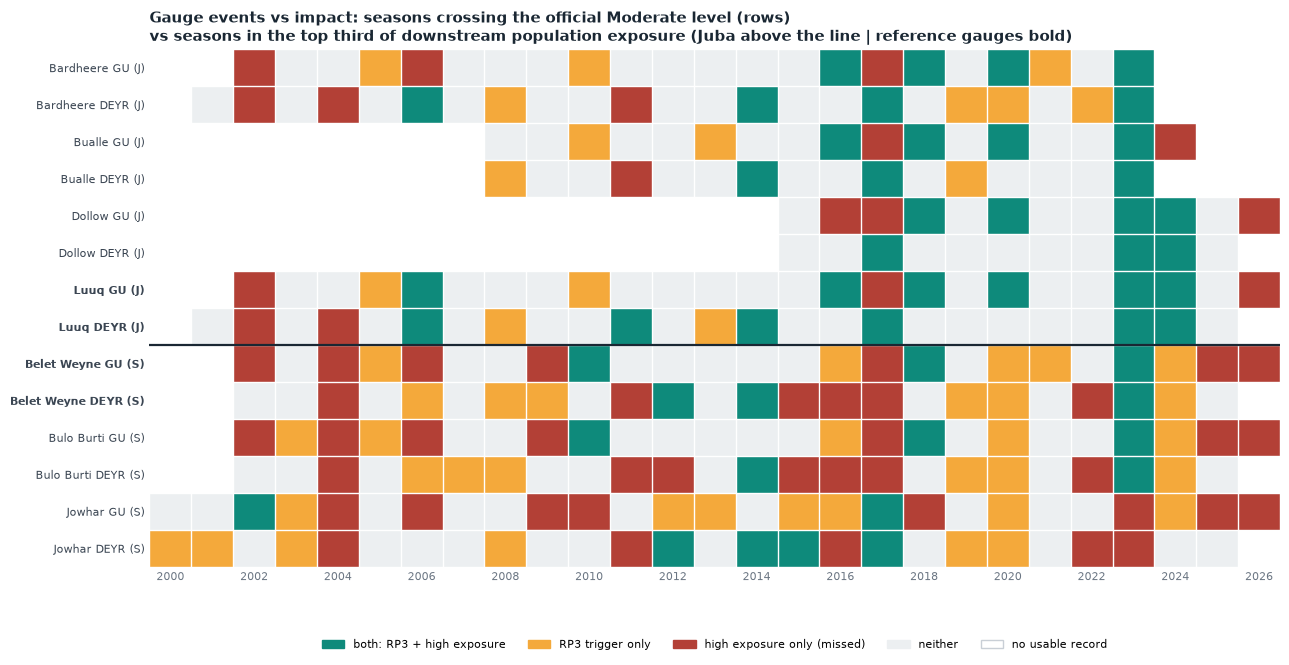

In [36]:
Y0, Y1 = 2000, 2026
years = list(range(Y0, Y1 + 1))
C_BOTH = "#0E8A7B"
C_TRIG = "#F4A93B"
C_MISS = "#B34036"
C_NONE = "#ECEFF1"
mat, labels, bold_rows = [], [], []
for river_l in ["juba", "shabelle"]:
    sub_act = act[act.river.str.lower() == river_l]
    for station in sorted(sub_act.station.unique()):
        for season in ["gu", "deyr"]:
            r = sub_act[
                (sub_act.station == station) & (sub_act.window == season)
            ]
            if not len(r):
                continue
            r = r.iloc[0]
            rec0, rec1 = [int(x) for x in r.record.split("-")]
            tyears = set(r.activation_years)
            eyears = exp_events[(river_l, season)]
            common = set(exp_series[(river_l, season)].index)
            row = []
            for y in years:
                if y not in common or y < rec0 or y > rec1:
                    row.append(
                        0
                    )  # no usable overlap of gauge + exposure record
                elif y in tyears and y in eyears:
                    row.append(3)
                elif y in tyears:
                    row.append(2)
                elif y in eyears:
                    row.append(1)
                else:
                    row.append(0.5)
            mat.append(row)
            bold_rows.append(station in REF.values())
            labels.append(f"{station} {season.upper()} ({river_l[0].upper()})")
n_juba = sum(1 for lab in labels if lab.endswith("(J)"))
cmap = mcolors.ListedColormap(["#FFFFFF", C_NONE, C_MISS, C_TRIG, C_BOTH])
bounds = [-0.1, 0.2, 0.7, 1.5, 2.5, 3.5]
norm = mcolors.BoundaryNorm(bounds, cmap.N)
fig, ax = plt.subplots(figsize=(13, 0.34 * len(labels) + 2.0))
ax.imshow(mat, cmap=cmap, norm=norm, aspect="auto")
ax.set_xticks(range(0, len(years), 2))
ax.set_xticklabels(years[::2], fontsize=8)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=8)
for tick, bold in zip(ax.get_yticklabels(), bold_rows):
    if bold:
        tick.set_fontweight("bold")
ax.set_xticks([x - 0.5 for x in range(len(years) + 1)], minor=True)
ax.set_yticks([y - 0.5 for y in range(len(labels) + 1)], minor=True)
ax.grid(which="minor", color="white", linewidth=1.0)
ax.tick_params(which="both", length=0)
for s in ax.spines.values():
    s.set_visible(False)
ax.axhline(n_juba - 0.5, color=INK, lw=1.6)
ax.legend(
    handles=[
        mpatches.Patch(color=C_BOTH, label="both: RP3 + high exposure"),
        mpatches.Patch(color=C_TRIG, label="RP3 trigger only"),
        mpatches.Patch(color=C_MISS, label="high exposure only (missed)"),
        mpatches.Patch(color=C_NONE, label="neither"),
        mpatches.Patch(
            facecolor="#FFFFFF", edgecolor="#C9CFD6", label="no usable record"
        ),
    ],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=5,
    fontsize=8,
)
ax.set_title(
    "Gauge events vs impact: seasons crossing the official Moderate level (rows)\n"
    "vs seasons in the top third of downstream population exposure (Juba above the line | reference gauges bold)",
    fontsize=11,
)
plt.tight_layout()

### Where exactly is that exposure?

The comparison above sums exposure over all districts in each river's set,
so it hides geography. The map below shows the district-level picture: each
riverine district colored by its typical yearly peak population exposed
(median across 1998-2025 of the highest single-day exposed population in
each year). Grey districts are outside the 10 km river buffers and are not
part of the comparison.


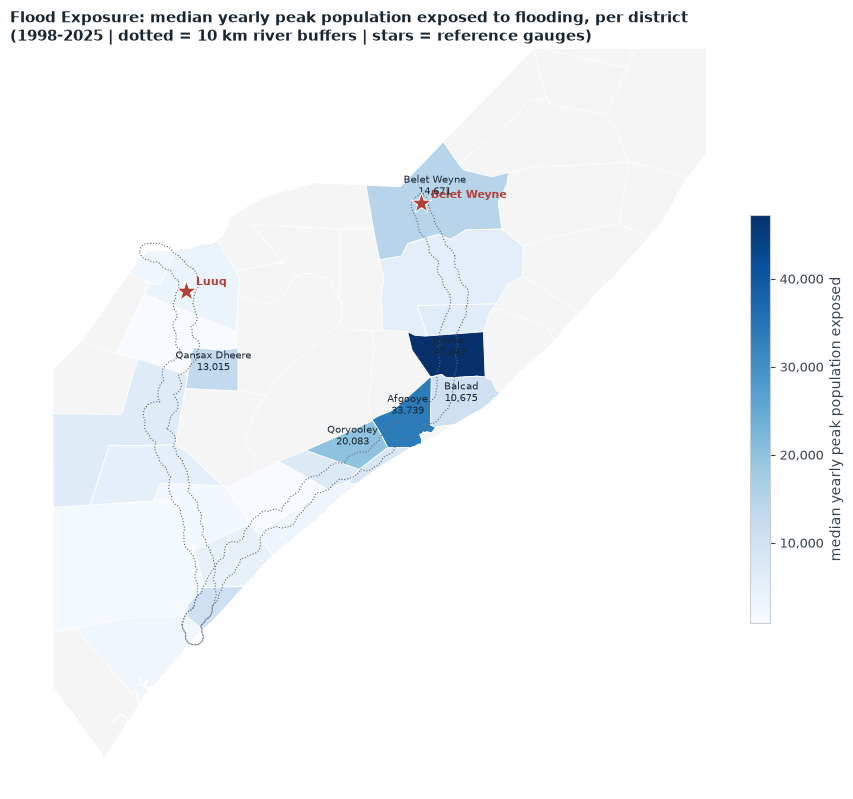

In [37]:
# typical yearly peak exposed population per district:
# median across years of each year's highest single-day exposure
dist_peak = (
    exp.groupby([exp.valid_date.dt.year, "pcode"])["sum"]
    .max()
    .groupby("pcode")
    .median()
    .rename("peak_exposed")
)
riverine = adm2.merge(
    dist_peak.reset_index(), left_on="ADM2_PCODE", right_on="pcode"
)

fig, ax = plt.subplots(figsize=(9, 8))
adm2.plot(ax=ax, color="#F5F5F5", edgecolor="white", linewidth=0.5)
riverine.plot(
    ax=ax,
    column="peak_exposed",
    cmap="Blues",
    edgecolor="white",
    linewidth=0.6,
    legend=True,
    legend_kwds={
        "label": "median yearly peak population exposed",
        "shrink": 0.55,
        "format": FuncFormatter(lambda v, _: f"{v:,.0f}"),
    },
)
bufs.plot(
    ax=ax, color="none", edgecolor="#5C6B7A", linewidth=0.8, linestyle=":"
)
for key in ["belet_weyne", "luuq"]:
    st = STATIONS[key]
    ax.scatter(
        st.lon,
        st.lat,
        marker="*",
        s=240,
        color="#B34036",
        edgecolors="white",
        linewidths=0.7,
        zorder=6,
    )
    ax.annotate(
        st.name,
        (st.lon, st.lat),
        textcoords="offset points",
        xytext=(7, 4),
        fontsize=8,
        color="#B34036",
        fontweight="bold",
    )
for _, r in riverine.nlargest(6, "peak_exposed").iterrows():
    pt = r.geometry.representative_point()
    ax.annotate(
        f"{r.ADM2_EN}\n{r.peak_exposed:,.0f}",
        (pt.x, pt.y),
        ha="center",
        fontsize=7,
        color=INK,
    )
ax.set_xlim(40.5, 48.5)
ax.set_ylim(-2, 6.5)
ax.set_title(
    "Flood Exposure: median yearly peak population exposed to flooding, per district\n"
    "(1998-2025 | dotted = 10 km river buffers | stars = reference gauges)",
    fontsize=11,
)
ax.set_axis_off()
plt.tight_layout()

## Context: what the full record would have given

The operative RP levels above are already post-2000. This section shows
the full-record fit alongside them: the gap (hollow to filled dots) is
the size of the nonstationarity correction.

The nonstationarity warning above, acted on: the same Weibull RP3
computation restricted to years 2000 onward. This is the modern-gauge,
wetter-regime record: the fit the operational thresholds should use.
Side-by-side with the full-record fit and the position in the official
band (0% = Moderate | 100% = High).

In [38]:
# the operative rp_levels are post-2000; compute the FULL-record fit here
# purely as context, to show what the old convention would have given
rows = []
for sn, df in levels.items():
    s = df["level(m)"].dropna()
    name = thresholds.loc[sn, "Station Name"] if sn in thresholds.index else sn
    river = thresholds.loc[sn, "River"] if sn in thresholds.index else ""
    for window in ["gu", "deyr"]:
        months = SEASON_MONTHS[window]
        sub = s[s.index.month.isin(months)]
        am = sub.groupby(sub.index.year).max().dropna()
        if len(am) < 8:
            continue
        rows.append(
            {
                "station": name,
                "river": river,
                "code": sn,
                "window": window,
                "n_years_fullrecord": len(am),
                "rp3_fullrecord_m": round(weibull_level(am.values, 3), 2),
            }
        )
rp3_full = pd.DataFrame(rows)
cmp = rp3_full.merge(
    rp_levels[rp_levels.window != "any"][
        ["code", "window", "rp3_level_m", "moderate_m", "high_m"]
    ],
    on=["code", "window"],
    how="left",
).rename(columns={"rp3_level_m": "rp3_post2000_m"})
cmp["shift_m"] = (cmp.rp3_post2000_m - cmp.rp3_fullrecord_m).round(2)
cmp["position_pct_post2000"] = (
    (cmp.rp3_post2000_m - cmp.moderate_m) / (cmp.high_m - cmp.moderate_m) * 100
).round(0)
cmp.sort_values(["river", "station", "window"])[
    [
        "station",
        "river",
        "window",
        "n_years_fullrecord",
        "rp3_fullrecord_m",
        "rp3_post2000_m",
        "shift_m",
        "moderate_m",
        "high_m",
        "position_pct_post2000",
    ]
].reset_index(drop=True)

,station,river,window,n_years_fullrecord,rp3_fullrecord_m,rp3_post2000_m,shift_m,moderate_m,high_m,position_pct_post2000
0,Bardheere,Juba,deyr,43,7.35,9.00,1.65,7.4,8.20,200.0
1,Bardheere,Juba,gu,40,7.25,7.82,0.57,7.4,8.20,53.0
2,Bualle,Juba,deyr,16,7.27,7.27,0.00,9.0,10.00,-173.0
3,Bualle,Juba,gu,17,6.41,6.41,0.00,9.0,10.00,-259.0
4,Dollow,Juba,deyr,10,5.09,5.09,0.00,4.5,5.00,118.0
5,Dollow,Juba,gu,12,5.27,5.27,0.00,4.5,5.00,154.0
6,Kaitoi,Juba,deyr,9,5.29,NaN,NaN,NaN,NaN,NaN
7,Kaitoi,Juba,gu,9,5.08,NaN,NaN,NaN,NaN,NaN
8,Luuq,Juba,deyr,61,5.01,5.34,0.33,5.5,6.00,-32.0
9,Luuq,Juba,gu,59,4.48,5.23,0.75,5.5,6.00,-54.0


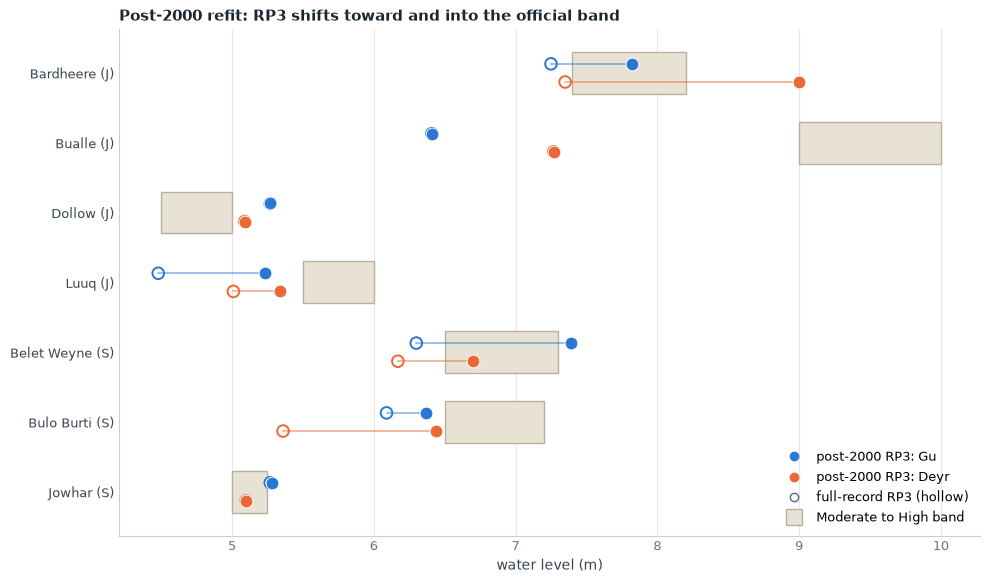

In [39]:
plot_c = cmp[cmp.moderate_m.notna() & cmp.high_m.notna()].copy()
stations_c = plot_c.drop_duplicates("station").sort_values(
    ["river", "station"]
)
ypos = {st: i for i, st in enumerate(stations_c.station)}
fig, ax = plt.subplots(figsize=(10, 0.62 * len(ypos) + 1.6))
W_COLORS = {"gu": C_GU, "deyr": C_DEYR}
for _, r in stations_c.iterrows():
    y = ypos[r.station]
    ax.barh(
        y,
        r.high_m - r.moderate_m,
        left=r.moderate_m,
        height=0.6,
        color=C_BAND,
        edgecolor=C_BAND_EDGE,
        linewidth=1.0,
        zorder=2,
    )
for _, r in plot_c.iterrows():
    y = ypos[r.station] + (-0.13 if r.window == "gu" else 0.13)
    ax.scatter(
        r.rp3_fullrecord_m,
        y,
        facecolors="none",
        edgecolors=W_COLORS[r.window],
        s=70,
        zorder=4,
        linewidths=1.4,
    )
    ax.scatter(
        r.rp3_post2000_m,
        y,
        color=W_COLORS[r.window],
        s=85,
        zorder=5,
        edgecolors="white",
        linewidths=0.7,
    )
    ax.plot(
        [r.rp3_fullrecord_m, r.rp3_post2000_m],
        [y, y],
        color=W_COLORS[r.window],
        lw=1.1,
        alpha=0.6,
        zorder=3,
    )
labels_c = [f"{r.station} ({r.river[0]})" for _, r in stations_c.iterrows()]
ax.set_yticks(range(len(ypos)))
ax.set_yticklabels(labels_c, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("water level (m)")
handles = [
    plt.Line2D(
        [], [], color=C_GU, marker="o", ls="", label="post-2000 RP3: Gu"
    ),
    plt.Line2D(
        [], [], color=C_DEYR, marker="o", ls="", label="post-2000 RP3: Deyr"
    ),
    plt.Line2D(
        [],
        [],
        color=C_REF,
        marker="o",
        markerfacecolor="none",
        ls="",
        label="full-record RP3 (hollow)",
    ),
    plt.Line2D(
        [],
        [],
        color=C_BAND,
        marker="s",
        ls="",
        markersize=12,
        markeredgecolor=C_BAND_EDGE,
        label="Moderate to High band",
    ),
]
ax.legend(handles=handles, loc="lower right")
ax.set_title(
    "Post-2000 refit: RP3 shifts toward and into the official band",
    fontsize=11,
)
style_ax(ax)
plt.tight_layout()

### Bardheere data quality: the 9.00 m refit value is an artifact

Inspection of the raw readings behind the post-2000 Deyr RP3 of 9.00 m:

1. **The record is right-censored at Bank Full**: Deyr 2023 sits pinned at
   exactly 10.40 m for 15 consecutive days (Nov 3-22): the true peak is
   unknown, only ">= 10.4" is.
2. **9.00 m is a magnet value**: it appears 54 times (2014-2023: 18 days in
   2018 | 11 in 2020 | 9 in 2023), while neighbouring values appear once or
   twice: the gauge saturates or staff round at 9.00. Several seasonal
   maxima are therefore exactly 9.00, and the rank-interpolated RP3 lands on
   that pin.
3. **Post-destruction entries**: the gauge was destroyed 8 Nov 2023, yet
   values continue at exactly 10.40 through 22 Nov, followed by two
   spurious 0.00 readings (24 and 30 Nov): nominal entries, not
   measurements.

**Practical rule**: do not use the 9.00 m refit for Bardheere. Anchor on the
official Moderate (7.4 m, which equals the full-record RP3) and treat any
reading >= 9.0 as "at or beyond gauge saturation". This censoring also
inflates the observed-discharge record used in the model bias check, which
is consistent with every model appearing "too dry" at Bardheere.

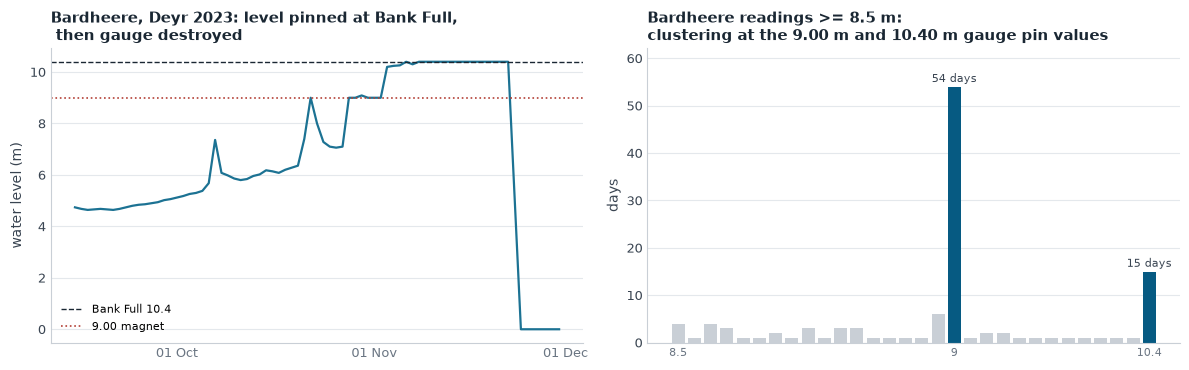

In [40]:
b = levels["jb002"]["level(m)"].dropna()
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
d = b.loc["2023-09-15":"2023-12-05"]
axes[0].plot(d.index, d.values, color=C_MAIN, lw=1.6)
axes[0].axhline(10.4, color=INK, ls="--", lw=1, label="Bank Full 10.4")
axes[0].axhline(9.0, color=C_HIGH, ls=":", lw=1.2, label="9.00 magnet")
axes[0].set_ylabel("water level (m)")
axes[0].xaxis.set_major_locator(mdates.MonthLocator())
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
axes[0].set_title(
    "Bardheere, Deyr 2023: level pinned at Bank Full, \n then gauge destroyed",
    fontsize=10.5,
)
axes[0].legend(fontsize=8)
style_ax(axes[0], grid="y")

top = b[b >= 8.5].round(2).value_counts().sort_index()
pin_vals = [9.0, 10.4]
bar_colors = [
    "#065A82" if any(np.isclose(v, p) for p in pin_vals) else "#C9CFD6"
    for v in top.index
]
axes[1].bar(range(len(top)), top.values, color=bar_colors)
tick_vals = [8.5, 9.0, 9.5, 10.0, 10.4]
keep = [
    i
    for i, v in enumerate(top.index)
    if any(np.isclose(v, t) for t in tick_vals)
]
axes[1].set_xticks(keep)
axes[1].set_xticklabels([f"{top.index[i]:g}" for i in keep], fontsize=8)
for i, v in enumerate(top.index):
    if any(np.isclose(v, p) for p in pin_vals):
        axes[1].text(
            i,
            top.values[i] + 1,
            f"{int(top.values[i])} days",
            ha="center",
            fontsize=8,
            color=BODY,
        )
axes[1].set_ylim(0, top.values.max() * 1.15)
axes[1].set_ylabel("days")
axes[1].set_title(
    "Bardheere readings >= 8.5 m: \nclustering at the 9.00 m and 10.40 m gauge pin values",
    fontsize=10.5,
)
style_ax(axes[1], grid="y")
plt.tight_layout()